In [1]:
import pandas as pd
import numpy as np

# Configuración de rutas
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

def capa_0_datos(path):
    """
    Capa 0: Carga, Warm-up de indicadores (1m y 1h) y Filtrado de Sesión.
    """
    print(f"🚀 Cargando dataset desde: {path}")
    
    # 1. Carga del archivo Parquet
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    
    # Asegurar zona horaria local (NY)
    if df.index.tz is not None:
        df.index = df.index.tz_convert('America/New_York').tz_localize(None)
    
    # 2. EMAs de 1 Minuto
    for p in [1, 9, 12, 21, 50]:
        df[f'ema_1m_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()
        
    # 3. EMAs de 1 Hora (Indicadores de Marea)
    # Calculamos sobre resample de 1h para precisión estructural
    df_h1 = df['Close'].resample('1h').last().dropna().to_frame()
    
    periodos_h1 = [20, 50, 100, 200]
    for p in periodos_h1:
        col_name = f'ema_1h_{p}'
        # Calculamos EMA y aplicamos shift(1) para usar solo velas cerradas
        ema_values = df_h1['Close'].ewm(span=p, adjust=False).mean().shift(1)
        # Reindexamos al dataframe de 1 minuto (df) con forward-fill
        df[col_name] = ema_values.reindex(df.index, method='ffill')
    
    # 4. Filtrado de Sesión Operativa (09:30 a 18:00)
    df_session = df.between_time('09:30', '18:00').copy()
    
    # Limpieza de registros iniciales (esperamos a la EMA 200h)
    df_session = df_session.dropna(subset=['ema_1h_200'])
    
    print(f"✅ Capa 0 Completada. Indicadores de Marea listos: {periodos_h1}")
    return df_session

# --- EJECUCIÓN ---
df_ready = capa_0_datos(FILE_PATH_PARQUET)
df_ready.head()

🚀 Cargando dataset desde: /home/quant/data/processed/nq_1m_continuous.parquet
✅ Capa 0 Completada. Indicadores de Marea listos: [20, 50, 100, 200]


,Open,High,Low,Close,Volume,Ticker,ema_1m_1,ema_1m_9,ema_1m_12,ema_1m_21,ema_1m_50,ema_1h_20,ema_1h_50,ema_1h_100,ema_1h_200
timestamp,,,,,,,,,,,,,,,
2010-06-07 09:30:00,1841.25,1842.00,1838.75,1841.00,3113,NQM0,1841.00,1840.032226,1839.864509,1839.805139,1840.221120,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:31:00,1840.75,1843.75,1840.50,1842.75,1596,NQM0,1842.75,1840.575781,1840.308431,1840.072854,1840.320292,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:32:00,1842.75,1844.25,1841.50,1843.75,1377,NQM0,1843.75,1841.210625,1840.837903,1840.407140,1840.454791,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:33:00,1843.75,1844.00,1839.50,1839.50,1274,NQM0,1839.50,1840.868500,1840.632072,1840.324672,1840.417348,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:34:00,1839.50,1840.75,1837.00,1837.75,1566,NQM0,1837.75,1840.244800,1840.188676,1840.090611,1840.312746,1827.324773,1823.387119,1821.781056,1820.913594


In [2]:
import pandas as pd
import numpy as np

def generar_trades_orb(df, breakout_delta=5.0):
    """
    Capa 1: Lógica de detección de ORB, confirmación de Breakout y ejecución en Midpoint.
    Limitado a 1 trade por día.
    """
    print(f"distancia de confirmación (BreakoutDelta): {breakout_delta} puntos.")
    
    # 1. Identificar días únicos en el dataset
    df['date'] = df.index.date
    unique_days = df['date'].unique()
    trades = []

    for day in unique_days:
        # Filtrar data del día
        df_day = df[df['date'] == day].copy()
        
        # 2. Definir el Rango ORB (09:30 - 09:34 inclusive)
        # Las primeras 5 velas de 1m definen el rango de 5m
        orb_data = df_day.between_time('09:30', '09:34')
        if len(orb_data) < 5:
            continue
            
        orb_h = orb_data['High'].max()
        orb_l = orb_data['Low'].min()
        orb_m = (orb_h + orb_l) / 2
        
        # 3. Buscar Confirmación de Breakout (Post 09:34)
        # Solo evaluamos velas a partir de las 09:35
        post_orb = df_day.between_time('09:35', '16:00')
        
        confirmed_dir = None
        confirmation_time = None
        
        for ts, row in post_orb.iterrows():
            # Condición Long: Vela completa a distancia Delta sobre el High
            if row['Low'] >= (orb_h + breakout_delta):
                confirmed_dir = 'Long'
                confirmation_time = ts
                break
            
            # Condición Short: Vela completa a distancia Delta bajo el Low
            if row['High'] <= (orb_l - breakout_delta):
                confirmed_dir = 'Short'
                confirmation_time = ts
                break
        
        # 4. Si hay confirmación, buscar Retest al Midpoint
        if confirmed_dir:
            # Buscamos la entrada desde el minuto siguiente a la confirmación
            retest_data = post_orb.loc[confirmation_time:].iloc[1:]
            
            entry_time = None
            entry_price = orb_m
            
            for ts_entry, row_entry in retest_data.iterrows():
                # El precio debe cruzar o tocar el midpoint para gatillar
                if confirmed_dir == 'Long':
                    # En un Long, venimos de arriba, buscamos Low <= Midpoint
                    if row_entry['Low'] <= orb_m:
                        entry_time = ts_entry
                        break
                else:
                    # En un Short, venimos de abajo, buscamos High >= Midpoint
                    if row_entry['High'] >= orb_m:
                        entry_time = ts_entry
                        break
            
            # 5. Registrar el Trade si hubo entrada
            if entry_time:
                # Valores adicionales importantes para optimización
                trade_info = {
                    'fecha': day,
                    'orb_high': orb_h,
                    'orb_low': orb_l,
                    'midpoint': orb_m,
                    'direccion': confirmed_dir,
                    'confirmacion_dt': confirmation_time,
                    'entrada_dt': entry_time,
                    'entrada_precio': entry_price,
                    # Referencias de mercado al momento de entrada
                    'ema_1h_50_entry': row_entry['ema_1h_50'],
                    'ema_1m_21_entry': row_entry['ema_1m_21'],
                    'ticker': row_entry['Ticker']
                }
                trades.append(trade_info)
                # Req Inmutable: Solo 1 trade al día. Pasamos al siguiente día.
                continue

    # Convertir a DataFrame de Trades
    df_trades = pd.DataFrame(trades)
    
    if not df_trades.empty:
        df_trades['entrada_dt'] = pd.to_datetime(df_trades['entrada_dt'])
        print(f"✅ Procesamiento completado. Trades generados: {len(df_trades)}")
    else:
        print("⚠️ No se generaron trades con los parámetros actuales.")
        
    return df_trades

# --- EJECUCIÓN ---
# Nota: df_ready viene de la Capa 0
df_trades_raw = generar_trades_orb(df_ready, breakout_delta=5.0)
df_trades_raw.head()

distancia de confirmación (BreakoutDelta): 5.0 puntos.
✅ Procesamiento completado. Trades generados: 2385


,fecha,orb_high,orb_low,midpoint,direccion,confirmacion_dt,entrada_dt,entrada_precio,ema_1h_50_entry,ema_1m_21_entry,ticker
0,2010-06-07,1844.25,1837.00,1840.625,Short,2010-06-07 09:43:00,2010-06-07 09:53:00,1840.625,1823.387119,1835.366356,NQM0
1,2010-06-08,1803.50,1796.50,1800.000,Short,2010-06-08 09:54:00,2010-06-08 11:57:00,1800.000,1810.597340,1794.184535,NQM0
2,2010-06-09,1808.75,1804.75,1806.750,Short,2010-06-09 10:05:00,2010-06-09 10:51:00,1806.750,1799.436594,1801.177908,NQM0
3,2010-06-10,1809.25,1801.00,1805.125,Long,2010-06-10 10:01:00,2010-06-10 12:44:00,1805.125,1796.663916,1808.125132,NQM0
4,2010-06-14,1864.25,1859.50,1861.875,Long,2010-06-14 10:17:00,2010-06-14 13:07:00,1861.875,1838.232442,1865.321516,NQU0


In [3]:
import pandas as pd
import numpy as np

def simular_gestion_riesgo(df_ready, df_trades, breakout_delta=5.0):
    """
    Capa 2: Simulación de gestión de riesgo con modelo secuencial OHLC/OLHC.
    Salidas: TP (2R), SL (Extremo ORB), BE (al tocar 1R).
    """
    print(f"🚀 Iniciando gestión de riesgo para {len(df_trades)} trades...")
    
    resultados = []

    for _, trade in df_trades.iterrows():
        # Extraer parámetros del trade
        entry_price = trade['entrada_precio']
        direction = trade['direccion']
        orb_h = trade['orb_high']
        orb_l = trade['orb_low']
        
        # Calcular distancias de riesgo (R)
        # R es la distancia del midpoint al extremo del ORB
        risk_r = abs(entry_price - (orb_l if direction == 'Long' else orb_h))
        
        stop_loss = orb_l if direction == 'Long' else orb_h
        take_profit = entry_price + (2 * risk_r) if direction == 'Long' else entry_price - (2 * risk_r)
        be_trigger = entry_price + risk_r if direction == 'Long' else entry_price - risk_r
        
        # Obtener data desde el minuto de entrada hasta el fin de sesión
        df_day = df_ready[df_ready.index.date == trade['fecha']]
        df_post_entry = df_day.loc[trade['entrada_dt']:]
        
        current_sl = stop_loss
        be_activated = False
        exit_price = None
        exit_time = None
        exit_reason = None
        
        for ts, row in df_post_entry.iterrows():
            # Modelo Secuencial OHLC/OLHC para resolver conflictos intra-vela
            if row['Open'] <= row['Close']:
                # Vela Alcista: Open -> Low -> High -> Close
                sequence = [row['Open'], row['Low'], row['High'], row['Close']]
            else:
                # Vela Bajista: Open -> High -> Low -> Close
                sequence = [row['Open'], row['High'], row['Low'], row['Close']]
                
            for price_point in sequence:
                # 1. Verificar Trigger de Break Even (1R)
                if not be_activated:
                    if (direction == 'Long' and price_point >= be_trigger) or \
                       (direction == 'Short' and price_point <= be_trigger):
                        current_sl = entry_price
                        be_activated = True
                
                # 2. Verificar Stop Loss (o BE si ya se activó)
                if (direction == 'Long' and price_point <= current_sl) or \
                   (direction == 'Short' and price_point >= current_sl):
                    exit_price = current_sl
                    exit_time = ts
                    exit_reason = 'SL' if not be_activated else 'BE'
                    break
                
                # 3. Verificar Take Profit (2R)
                if (direction == 'Long' and price_point >= take_profit) or \
                   (direction == 'Short' and price_point <= take_profit):
                    exit_price = take_profit
                    exit_time = ts
                    exit_reason = 'TP'
                    break
            
            if exit_time: break
            
        # 4. Cierre forzado EOD si no salió por niveles
        if not exit_time:
            exit_price = df_post_entry['Close'].iloc[-1]
            exit_time = df_post_entry.index[-1]
            exit_reason = 'EOD'

        # Cálculo de PnL en R
        pnl_r = (exit_price - entry_price) / risk_r if direction == 'Long' else (entry_price - exit_price) / risk_r
        
        # Guardar resultado extendido
        res = trade.to_dict()
        res.update({
            'salida_dt': exit_time,
            'salida_precio': exit_price,
            'motivo': exit_reason,
            'pnl_r': pnl_r,
            'be_activado': be_activated,
            'risk_r_puntos': risk_r
        })
        resultados.append(res)

    df_results = pd.DataFrame(resultados)
    print(f"✅ Gestión completada. Win Rate: {(df_results['pnl_r'] > 0).mean():.2%}")
    return df_results

# --- EJECUCIÓN ---
# df_ready (Capa 0) y df_trades_raw (Capa 1) deben estar en memoria
df_final_results = simular_gestion_riesgo(df_ready, df_trades_raw)
df_final_results[['fecha', 'direccion', 'motivo', 'pnl_r']].head(10)

🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%


,fecha,direccion,motivo,pnl_r
0,2010-06-07,Short,SL,-1.0
1,2010-06-08,Short,TP,2.0
2,2010-06-09,Short,BE,0.0
3,2010-06-10,Long,TP,2.0
4,2010-06-14,Long,BE,0.0
5,2010-06-17,Short,TP,2.0
6,2010-06-18,Long,SL,-1.0
7,2010-06-22,Long,BE,0.0
8,2010-06-23,Short,SL,-1.0
9,2010-06-24,Short,SL,-1.0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_estrategia_v2(df_results):
    """
    Capa 4: Reporte de Performance (Baseline V38).
    """
    print("\n📊 Generando reporte de evaluación (Baseline V38)...")
    
    # Filtro de Ventanas Operativas Inmutables
    def esta_en_ventana(hora_str):
        h, m = map(int, hora_str.split(':'))
        t = h * 60 + m
        ventanas = [(600, 660), (720, 780), (840, 900)]
        return any(inicio <= t < fin for inicio, fin in ventanas)

    df_filtered = df_results.copy()
    if 'hora_entrada' not in df_filtered.columns:
        df_filtered['hora_entrada'] = pd.to_datetime(df_filtered['entrada_dt']).dt.strftime('%H:%M')

    df_filtered = df_filtered[df_filtered['hora_entrada'].apply(esta_en_ventana)].copy()
    df_filtered = df_filtered.sort_values('fecha').copy()
    df_filtered['pnl_acumulado'] = df_filtered['pnl_r'].cumsum()
    
    perdida_total = abs(df_filtered[df_filtered['pnl_r'] < 0]['pnl_r'].sum())
    profit_factor = df_filtered[df_filtered['pnl_r'] > 0]['pnl_r'].sum() / perdida_total if perdida_total != 0 else np.inf
    
    print("-" * 35)
    print(f"✅ BASELINE VALIDADO")
    print(f"Total Trades:      {len(df_filtered)}")
    print(f"Resultado Final:   {df_filtered['pnl_acumulado'].iloc[-1]:.2f} R")
    print(f"Profit Factor:     {profit_factor:.2f}")
    print("-" * 35)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(range(len(df_filtered)), df_filtered['pnl_acumulado'], color='#2563eb', lw=2)
    axes[0].set_title("Curva de Equidad (Acumulado R)")
    
    df_filtered['dia_semana'] = pd.to_datetime(df_filtered['fecha']).dt.day_name()
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    sns.barplot(x='dia_semana', y='pnl_r', data=df_filtered, order=order, ax=axes[1], 
                hue='dia_semana', palette='viridis', legend=False)
    axes[1].set_title("Expectancia por Día")
    plt.tight_layout(); plt.show()
    
    return df_filtered

def analizar_atribucion_marea(df_baseline, df_ready_mod):
    """
    Analiza qué EMA H1 (Marea) filtra mejor los trades malos del Baseline.
    """
    print("\n🕵️ Analizando Atribución de Marea (Filtros H1)...")
    periodos = [20, 50, 100, 200]
    analisis = []
    
    df_trades = df_baseline.copy().sort_values('entrada_dt')
    df_trades['entrada_dt'] = pd.to_datetime(df_trades['entrada_dt'])
    
    # Preparamos la fuente de indicadores (EMA H1 desde df_ready)
    df_source = df_ready_mod[[f'EMA_1h_{p}' for p in periodos]].copy().reset_index()
    df_source = df_source.rename(columns={df_source.columns[0]: 'entrada_dt'})
    df_source['entrada_dt'] = pd.to_datetime(df_source['entrada_dt'])

    # Unimos trades con la foto de las EMAs en el momento de la entrada
    df_merged = pd.merge_asof(df_trades, df_source, on='entrada_dt', direction='backward')
    
    for p in periodos:
        col_ema = f'EMA_1h_{p}'
        # Identificar si el trade fue "A Favor de la Marea"
        df_merged['a_favor'] = np.where(
            df_merged['direccion'] == 'Long',
            df_merged['entrada_precio'] > df_merged[col_ema],
            df_merged['entrada_precio'] < df_merged[col_ema]
        )
        
        df_favor = df_merged[df_merged['a_favor']].copy()
        if not df_favor.empty:
            ganancia = df_favor[df_favor['pnl_r'] > 0]['pnl_r'].sum()
            perdida = abs(df_favor[df_favor['pnl_r'] < 0]['pnl_r'].sum())
            pf = ganancia / perdida if perdida != 0 else np.inf
            
            analisis.append({
                'Filtro': f'EMA H1 {p}',
                'Profit Total (R)': round(df_favor['pnl_r'].sum(), 2),
                'Nº Trades': len(df_favor),
                'Win Rate': f"{(df_favor['pnl_r'] > 0).mean():.2%}",
                'Expectancy': round(df_favor['pnl_r'].mean(), 3),
                'Profit Factor': round(pf, 2),
                'Retención Vol.': f"{(len(df_favor)/len(df_baseline)):.1%}"
            })

    return pd.DataFrame(analisis)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CAPA 0: ACTUALIZACIÓN ESTRATÉGICA (EJECUTAR PRIMERO)
# =============================================================================
def inyectar_indicadores_marea(df_objetivo):
    """
    Inyecta las EMAs de 1 hora directamente en el DataFrame de mercado.
    Asegura que los nombres coincidan con el análisis de atribución.
    """
    print("🛠️ Capa 0: Inyectando indicadores de Marea (EMA H1)...")
    
    # 1. Resample a 1 Hora para cálculos HTF (High Time Frame)
    # Usamos el precio de cierre para la estructura de marea
    df_h1 = df_objetivo['Close'].resample('1h').last().dropna().to_frame()
    
 #   periodos = [20, 50, 100, 200]
    periodos = [100]

    for p in periodos:
        col_name = f'ema_1h_{p}'
        # Cálculo de EMA en temporalidad horaria
        ema_values = df_h1['Close'].ewm(span=p, adjust=False).mean()
        
        # Shift(1) para evitar look-ahead bias (operar con vela cerrada)
        # Reindexamos al timeframe de 1 minuto del DataFrame original
        df_objetivo[col_name] = ema_values.shift(1).reindex(df_objetivo.index, method='ffill')
        print(f"   ✅ {col_name} inyectada correctamente.")
        
    return df_objetivo

# =============================================================================
# CAPA 4: ANALÍTICA DE ATRIBUCIÓN
# =============================================================================
def analizar_atribucion_marea(df_trades, df_mercado):
    """
    Cruza los resultados de los trades con la marea del mercado.
    """
    print("\n🕵️ Analizando Atribución de Marea (Filtros H1)...")
    periodos = [20, 50, 100, 200]
    resumen = []
    
    # Asegurar formato de tiempo
    df_t = df_trades.copy()
    df_t['entrada_dt'] = pd.to_datetime(df_t['entrada_dt'])
    
    # Preparar fuente de datos de indicadores
    cols_ema = [f'ema_1h_{p}' for p in periodos]
    df_ema_source = df_mercado[cols_ema].copy().reset_index()
    df_ema_source = df_ema_source.rename(columns={df_ema_source.columns[0]: 'entrada_dt'})
    
    # Unir trades con indicadores mediante proximidad temporal
    df_merged = pd.merge_asof(df_t.sort_values('entrada_dt'), 
                             df_ema_source.sort_values('entrada_dt'), 
                             on='entrada_dt', 
                             direction='backward')
    
    for p in periodos:
        c = f'ema_1h_{p}'
        # Lógica de Marea: Precio > EMA (Long) | Precio < EMA (Short)
        df_merged['cumple_marea'] = np.where(
            df_merged['direccion'] == 'Long',
            df_merged['entrada_precio'] > df_merged[c],
            df_merged['entrada_precio'] < df_merged[c]
        )
        
        df_f = df_merged[df_merged['cumple_marea']]
        
        if not df_f.empty:
            ganancia = df_f[df_f['pnl_r'] > 0]['pnl_r'].sum()
            perdida = abs(df_f[df_f['pnl_r'] < 0]['pnl_r'].sum())
            pf = ganancia / perdida if perdida != 0 else np.inf
            
            resumen.append({
                'Filtro': f'EMA H1 {p}',
                'Profit (R)': round(df_f['pnl_r'].sum(), 2),
                'Trades': len(df_f),
                'Win Rate': f"{(df_f['pnl_r'] > 0).mean():.2%}",
                'Profit Factor': round(pf, 2),
                'Retención': f"{(len(df_f)/len(df_trades)):.1%}"
            })

    return pd.DataFrame(resumen)

# --- INSTRUCCIONES DE EJECUCIÓN (COPIAR A CELDA NUEVA) ---
# df_ready = inyectar_indicadores_marea(df_ready)
# reporte = analizar_atribucion_marea(df_final_results, df_ready)
# display(reporte)

In [6]:
import pandas as pd
import numpy as np

# =============================================================================
# CAPA 4: ANALÍTICA DE ATRIBUCIÓN DE MAREA (HTF)
# =============================================================================

def calcular_sortino(returns, target=0):
    """Calcula el Sortino Ratio basado en retornos de trades (R)."""
    if len(returns) < 2: return 0
    downside_returns = returns[returns < target]
    if len(downside_returns) < 2: return 0
    expected_return = returns.mean()
    downside_std = downside_returns.std()
    return (expected_return / downside_std) * np.sqrt(252) if downside_std != 0 else 0

def calcular_max_dd_r(pnl_series):
    """Calcula el Máximo Drawdown en términos de unidades R."""
    cumulative = pnl_series.cumsum()
    peak = cumulative.cummax()
    drawdown = cumulative - peak
    return drawdown.min()

def ejecutar_analisis_atribucion(df_trades, df_mercado):
    """
    Analiza el impacto de los filtros de Marea (EMA H1) sobre los resultados.
    Presenta los datos en formato de tabla comparativa avanzada incluyendo el Baseline.
    """
    print("🕵️ Analizando impacto de filtros de Marea (EMA H1)...")
    
    # Orden estricto solicitado: Sin Filtro seguido de EMAs por periodo
    casos = [None, 20, 50, 100, 200]
    resultados = []
    
    # 1. Preparar trades
    df_t = df_trades.copy()
    df_t['entrada_dt'] = pd.to_datetime(df_t['entrada_dt'])
    
    # 2. Preparar indicadores de marea desde df_ready (Capa 0)
    periodos_ema = [20, 50, 100, 200]
    cols_ema = [f'ema_1h_{p}' for p in periodos_ema]
    df_src = df_mercado[cols_ema].copy().reset_index()
    df_src = df_src.rename(columns={df_src.columns[0]: 'entrada_dt'})
    df_src['entrada_dt'] = pd.to_datetime(df_src['entrada_dt'])
    
    # 3. Unión asof para capturar estado de marea
    df_m = pd.merge_asof(df_t.sort_values('entrada_dt'), 
                        df_src.sort_values('entrada_dt'), 
                        on='entrada_dt', direction='backward')
    
    for p in casos:
        if p is None:
            nombre_filtro = "Sin Filtro"
            df_f = df_m.copy()
        else:
            nombre_filtro = f"EMA H1 {p}"
            c = f'ema_1h_{p}'
            # Filtro direccional: Precio > EMA en Long | Precio < EMA en Short
            df_m['cumple_marea'] = np.where(
                df_m['direccion'].str.contains('Long', case=False, na=False),
                df_m['entrada_precio'] > df_m[c],
                df_m['entrada_precio'] < df_m[c]
            )
            df_f = df_m[df_m['cumple_marea']].copy()
        
        if not df_f.empty:
            pnl = df_f['pnl_r']
            ganancia = pnl[pnl > 0].sum()
            perdida = abs(pnl[pnl < 0].sum())
            
            # Cálculo de métricas
            total_r = pnl.sum()
            n_trades = len(df_f)
            win_rate = (pnl > 0).mean()
            expectancy = total_r / n_trades
            sortino = calcular_sortino(pnl)
            pf = ganancia / perdida if perdida != 0 else np.inf
            max_dd = calcular_max_dd_r(pnl)
            
            resultados.append({
                'Filtro': nombre_filtro,
                'Profit Total (R)': total_r,
                'Nº Trades': n_trades,
                'Win Rate (%)': win_rate,
                'Expectancy (R)': expectancy,
                'Sortino': sortino,
                'Profit Factor': pf,
                'Max DD (R)': max_dd
            })
            
    # Convertimos a DataFrame
    df_res = pd.DataFrame(resultados)
    
    # Diccionario de formato para la visualización final
    format_dict = {
        'Profit Total (R)': '{:.2f} R',
        'Win Rate (%)': '{:.2%}',
        'Expectancy (R)': '{:.3f} R',
        'Sortino': '{:.2f}',
        'Profit Factor': '{:.2f}',
        'Max DD (R)': '{:.2f} R'
    }
    
    return df_res, format_dict

# --- EJECUCIÓN DEL REPORTE ---
reporte_marea, formatos = ejecutar_analisis_atribucion(df_final_results, df_ready)

if reporte_marea is not None:
    print("\n📊 TABLA DE ATRIBUCIÓN ESTRATÉGICA")
    # Presentación final estática con el formato solicitado
    display(reporte_marea.style.format(formatos))

🕵️ Analizando impacto de filtros de Marea (EMA H1)...

📊 TABLA DE ATRIBUCIÓN ESTRATÉGICA


,Filtro,Profit Total (R),Nº Trades,Win Rate (%),Expectancy (R),Sortino,Profit Factor,Max DD (R)
0,Sin Filtro,149.28 R,2385,24.11%,0.063 R,15.73,1.15,-38.17 R
1,EMA H1 20,61.32 R,1037,24.20%,0.059 R,18.76,1.14,-16.00 R
2,EMA H1 50,60.48 R,1175,24.00%,0.051 R,15.07,1.12,-30.00 R
3,EMA H1 100,78.83 R,1198,24.54%,0.066 R,16.31,1.16,-23.67 R
4,EMA H1 200,70.98 R,1187,24.26%,0.060 R,14.81,1.14,-27.29 R



📊 Análisis de Sensibilidad Sentinel (Caso Base vs Optimizados)
-------------------------------------------------------------------------------------
  N |      E | Trades |   Profit_R |      Exp |       WR |     PF |  MaxDD_R
-------------------------------------------------------------------------------------
BASE |      - |   1198 |     78.83R |   0.0658 |   24.54% |   1.16 |    23.67R (Marea 100)
-------------------------------------------------------------------------------------
  5 |  -0.10 |    704 |     45.26R |   0.0643 |   24.86% |   1.15 |    18.80R
  5 |  -0.05 |    701 |     45.26R |   0.0646 |   24.82% |   1.15 |    18.00R
  5 |  -0.01 |    701 |     45.26R |   0.0646 |   24.82% |   1.15 |    18.00R
  5 |   0.00 |    525 |     30.26R |   0.0576 |   25.14% |   1.13 |    20.80R
  5 |   0.01 |    525 |     30.26R |   0.0576 |   25.14% |   1.13 |    20.80R
  5 |   0.05 |    523 |     32.26R |   0.0617 |   25.24% |   1.15 |    18.80R
 10 |  -0.10 |    723 |     47.66R |   0.0

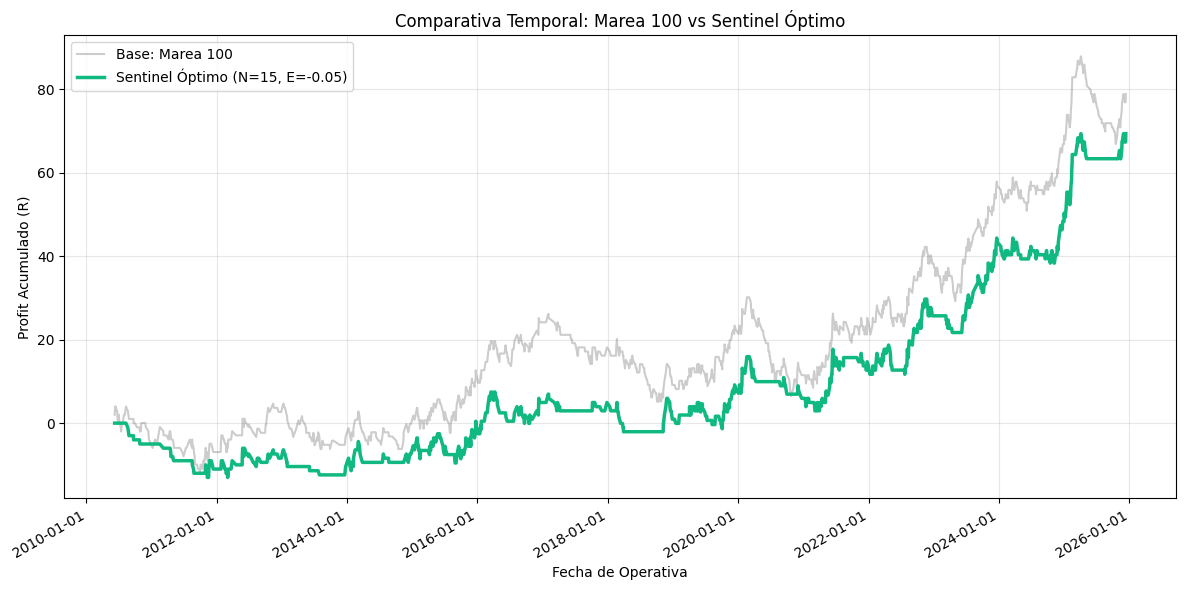

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=15, umbral_e=-0.05, verbose=True):
    """
    Motor Sentinel puro:
    1. Filtra por Marea 100 usando df_ready y df_final_results del origen.
    2. Aplica el interruptor de Esperanza Móvil (Sentinel).
    
    Configuración Óptima Actualizada (Máxima Eficiencia):
    - N=15, E=-0.05 -> Profit: 69.33R | Exp: 0.0985 | MaxDD: 13.00R | PF: 1.24
    """
    
    # --- PASO 1: RECONSTRUIR BASE MAREA 100 DESDE ORIGEN ---
    trades = df_trades.copy()
    trades['entrada_dt'] = pd.to_datetime(trades['entrada_dt'])
    
    # Indicador de marea del origen
    df_ema = df_mercado[['ema_1h_100']].copy().reset_index()
    df_ema = df_ema.rename(columns={df_ema.columns[0]: 'entrada_dt'})
    df_ema['entrada_dt'] = pd.to_datetime(df_ema['entrada_dt'])
    
    # Unión exacta con datos de mercado
    df_base = pd.merge_asof(
        trades.sort_values('entrada_dt'),
        df_ema.sort_values('entrada_dt'),
        on='entrada_dt',
        direction='backward'
    )
    
    # Filtro de Marea (Baseline de 1198 trades)
    df_base['cumple_marea'] = np.where(
        df_base['direccion'].str.contains('Long', case=False, na=False),
        df_base['entrada_precio'] > df_base['ema_1h_100'],
        df_base['entrada_precio'] < df_base['ema_1h_100']
    )
    
    df_marea = df_base[df_base['cumple_marea']].copy().reset_index(drop=True)
    
    # --- PASO 2: APLICAR LÓGICA SENTINEL ---
    # Esperanza Móvil
    df_marea['expectancy_rolling'] = df_marea['pnl_r'].rolling(window=ventana_n).mean()
    
    # Interruptor: El trade T se ejecuta si la esperanza de T-1 es > Umbral
    df_marea['sentinel_on'] = df_marea['expectancy_rolling'].shift(1) > umbral_e
    df_marea['sentinel_on'] = df_marea['sentinel_on'].fillna(True) # Arranque
    
    # Creamos una columna de PnL para Sentinel: PnL real si está ON, 0 si está OFF
    df_marea['pnl_sentinel'] = np.where(df_marea['sentinel_on'], df_marea['pnl_r'], 0)
    
    # Filtrado final (solo para reporte de trades ejecutados)
    df_sentinel = df_marea[df_marea['sentinel_on']].copy()
    
    # --- PASO 3: REPORTE ---
    if verbose:
        pnl_sent = df_sentinel['pnl_r'].sum()
        print(f"✅ Sentinel N={ventana_n} E={umbral_e} (Configuración Activa)")
        print(f"Trades: {len(df_sentinel)} | PnL: {pnl_sent:.2f}R | Exp: {df_sentinel['pnl_r'].mean():.3f}")
    
    return df_sentinel, df_marea

def optimizar_sentinel(df_trades, df_mercado):
    """
    Genera una tabla comparativa variando N (Ventana) y E (Umbral),
    incluyendo indicadores de riesgo y coloreado por consola.
    """
    # Códigos de color ANSI
    G = '\033[92m'  # Verde
    R = '\033[91m'  # Rojo
    Y = '\033[93m'  # Amarillo
    C = '\033[96m'  # Cian
    B = '\033[1m'   # Negrita
    END = '\033[0m' # Reset
    
    ventanas = [5, 10, 15, 20, 30, 50]
    umbrales = [-0.10, -0.05, -0.01, 0.0, 0.01, 0.05]
    
    print(f"\n{B}📊 Análisis de Sensibilidad Sentinel (Caso Base vs Optimizados){END}")
    
    header = f"{B}{'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}{END}"
    divider = "-" * 85
    print(divider)
    print(header)
    print(divider)
    
    # --- LÍNEA 1: CASO BASE ---
    _, df_base_marea = ejecutar_sentinel_real(df_trades, df_mercado, verbose=False)
    pnl_b = df_base_marea['pnl_r'].sum()
    n_b = len(df_base_marea)
    exp_b = df_base_marea['pnl_r'].mean()
    wr_b = (df_base_marea['pnl_r'] > 0).mean()
    pf_b = df_base_marea[df_base_marea['pnl_r'] > 0]['pnl_r'].sum() / abs(df_base_marea[df_base_marea['pnl_r'] < 0]['pnl_r'].sum())
    dd_b = (df_base_marea['pnl_r'].cumsum().cummax() - df_base_marea['pnl_r'].cumsum()).max()
    
    print(f"{Y}{'BASE':>3} | {'-':>6} | {n_b:>6} | {pnl_b:>9.2f}R | {exp_b:>8.4f} | {wr_b*100:>7.2f}% | {pf_b:>6.2f} | {dd_b:>8.2f}R{END} (Marea 100)")
    print(divider)

    for v in ventanas:
        for e in umbrales:
            df_res, _ = ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=v, umbral_e=e, verbose=False)
            
            pnl_series = df_res['pnl_r']
            pnl_total = pnl_series.sum()
            n_trades = len(df_res)
            exp = pnl_series.mean() if n_trades > 0 else 0
            wr = (pnl_series > 0).mean() if n_trades > 0 else 0
            
            ganancias = pnl_series[pnl_series > 0].sum()
            perdidas = abs(pnl_series[pnl_series < 0].sum())
            pf = ganancias / perdidas if perdidas != 0 else np.inf
            
            equity = pnl_series.cumsum()
            drawdown = (equity.cummax() - equity).max() if len(equity) > 0 else 0
            
            color_p = G if pnl_total > pnl_b else (Y if pnl_total > 0 else R)
            color_dd = G if drawdown < dd_b else R
            
            row = (f"{C}{v:>3}{END} | {C}{e:>6.2f}{END} | {n_trades:>6} | "
                   f"{color_p}{pnl_total:>9.2f}R{END} | {exp:>8.4f} | "
                   f"{wr*100:>7.2f}% | {Y if pf > pf_b else END}{pf:>6.2f}{END} | "
                   f"{color_dd}{drawdown:>8.2f}R{END}")
            print(row)
            
    print(divider)

# --- EJECUCIÓN CON DATOS REALES DEL KERNEL ---
if 'df_final_results' in globals() and 'df_ready' in globals():
    optimizar_sentinel(df_final_results, df_ready)
    
    # Ejecución de la configuración ÓPTIMA (N=15, E=-0.05)
    _, df_full_comparison = ejecutar_sentinel_real(df_final_results, df_ready, ventana_n=15, umbral_e=-0.05)
    
    # Visualización Curva de Equidad Normalizada por Fecha
    plt.figure(figsize=(12, 6))
    
    # Fechas para el eje X
    fechas = df_full_comparison['entrada_dt']
    
    # Equity Base (Marea 100)
    plt.plot(fechas, df_full_comparison['pnl_r'].cumsum(), label='Base: Marea 100', color='gray', alpha=0.4)
    
    # Equity Sentinel (PnL acumulado usando la columna que pone 0 en trades filtrados)
    plt.plot(fechas, df_full_comparison['pnl_sentinel'].cumsum(), label='Sentinel Óptimo (N=15, E=-0.05)', color='#10b981', lw=2.5)
    
    # Formatear eje X para fechas
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gcf().autofmt_xdate() # Rotar fechas para legibilidad
    
    plt.title("Comparativa Temporal: Marea 100 vs Sentinel Óptimo")
    plt.ylabel("Profit Acumulado (R)")
    plt.xlabel("Fecha de Operativa")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("🛑 Error Crítico: No se detectan 'df_final_results' o 'df_ready' en el entorno.")


📊 Análisis de Sensibilidad Sentinel (Caso Base vs Optimizados)
-------------------------------------------------------------------------------------
  N |      E | Trades |   Profit_R |      Exp |       WR |     PF |  MaxDD_R
-------------------------------------------------------------------------------------
BASE |      - |   1198 |     78.83R |   0.0658 |   24.54% |   1.16 |    23.67R (Marea 100)
-------------------------------------------------------------------------------------
  5 |  -0.10 |    704 |     45.26R |   0.0643 |   24.86% |   1.15 |    18.80R
  5 |  -0.05 |    701 |     45.26R |   0.0646 |   24.82% |   1.15 |    18.00R
  5 |  -0.01 |    701 |     45.26R |   0.0646 |   24.82% |   1.15 |    18.00R
  5 |   0.00 |    525 |     30.26R |   0.0576 |   25.14% |   1.13 |    20.80R
  5 |   0.01 |    525 |     30.26R |   0.0576 |   25.14% |   1.13 |    20.80R
  5 |   0.05 |    523 |     32.26R |   0.0617 |   25.24% |   1.15 |    18.80R
 10 |  -0.10 |    723 |     47.66R |   0.0

/tmp/ipykernel_27098/1292744024.py:97: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_anio = df_active.groupby('año').apply(calcular_metricas)
/tmp/ipykernel_27098/1292744024.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_mes = df_meses.groupby(['año', 'mes']).apply(calcular_metricas)


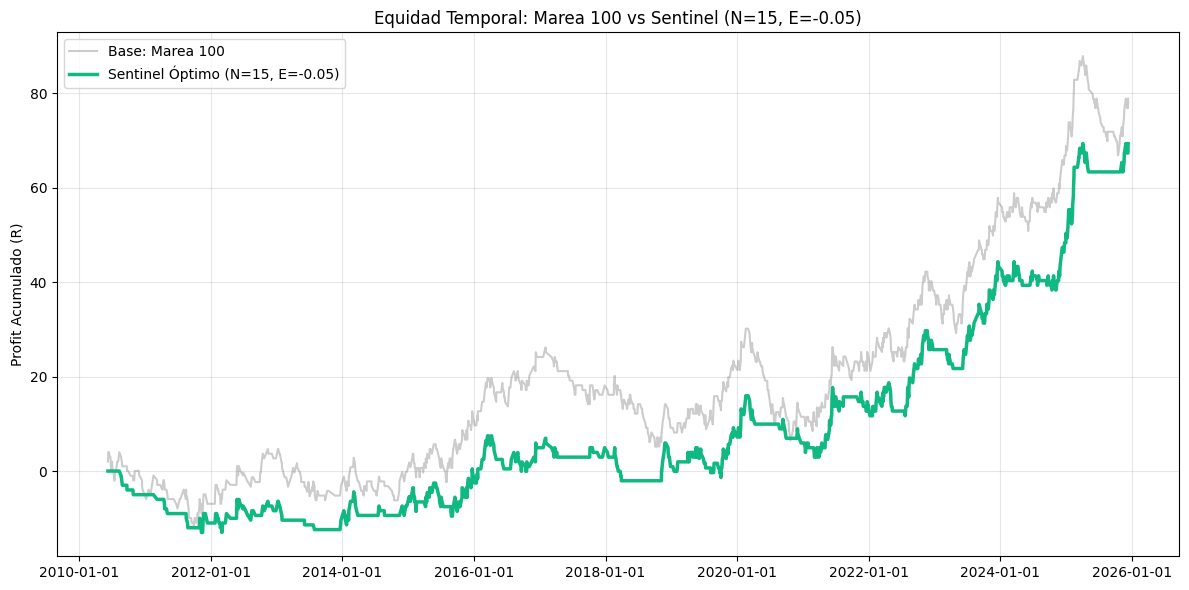

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=15, umbral_e=-0.05, verbose=True):
    """
    Motor Sentinel puro:
    1. Filtra por Marea 100 usando df_ready y df_final_results del origen.
    2. Aplica el interruptor de Esperanza Móvil (Sentinel).
    
    Configuración Óptima Actualizada (Máxima Eficiencia):
    - N=15, E=-0.05 -> Profit: 69.33R | Exp: 0.0985 | MaxDD: 13.00R | PF: 1.24
    """
    
    # --- PASO 1: RECONSTRUIR BASE MAREA 100 DESDE ORIGEN ---
    trades = df_trades.copy()
    trades['entrada_dt'] = pd.to_datetime(trades['entrada_dt'])
    
    # Indicador de marea del origen
    df_ema = df_mercado[['ema_1h_100']].copy().reset_index()
    df_ema = df_ema.rename(columns={df_ema.columns[0]: 'entrada_dt'})
    df_ema['entrada_dt'] = pd.to_datetime(df_ema['entrada_dt'])
    
    # Unión exacta con datos de mercado
    df_base = pd.merge_asof(
        trades.sort_values('entrada_dt'),
        df_ema.sort_values('entrada_dt'),
        on='entrada_dt',
        direction='backward'
    )
    
    # Filtro de Marea (Baseline de 1198 trades)
    df_base['cumple_marea'] = np.where(
        df_base['direccion'].str.contains('Long', case=False, na=False),
        df_base['entrada_precio'] > df_base['ema_1h_100'],
        df_base['entrada_precio'] < df_base['ema_1h_100']
    )
    
    df_marea = df_base[df_base['cumple_marea']].copy().reset_index(drop=True)
    
    # --- PASO 2: APLICAR LÓGICA SENTINEL ---
    # Esperanza Móvil
    df_marea['expectancy_rolling'] = df_marea['pnl_r'].rolling(window=ventana_n).mean()
    
    # Interruptor: El trade T se ejecuta si la esperanza de T-1 es > Umbral
    df_marea['sentinel_on'] = df_marea['expectancy_rolling'].shift(1) > umbral_e
    df_marea['sentinel_on'] = df_marea['sentinel_on'].fillna(True) # Arranque
    
    # Creamos una columna de PnL para Sentinel: PnL real si está ON, 0 si está OFF
    df_marea['pnl_sentinel'] = np.where(df_marea['sentinel_on'], df_marea['pnl_r'], 0)
    
    # Filtrado final (solo para reporte de trades ejecutados)
    df_sentinel = df_marea[df_marea['sentinel_on']].copy()
    
    # --- PASO 3: REPORTE ---
    if verbose:
        pnl_sent = df_sentinel['pnl_r'].sum()
        print(f"✅ Sentinel N={ventana_n} E={umbral_e} (Configuración Activa)")
        print(f"Trades: {len(df_sentinel)} | PnL: {pnl_sent:.2f}R | Exp: {df_sentinel['pnl_r'].mean():.3f}")
    
    return df_sentinel, df_marea

def imprimir_reporte_detallado(df_marea, ventana_n, umbral_e):
    """
    Genera tablas detalladas de métricas agrupadas por Año y por Mes (últimos 2 años).
    """
    G = '\033[92m'
    R = '\033[91m'
    B = '\033[1m'
    END = '\033[0m'
    
    df = df_marea.copy()
    df['año'] = df['entrada_dt'].dt.year
    df['mes'] = df['entrada_dt'].dt.month
    
    # Solo consideramos trades donde Sentinel estuvo ON
    df_active = df[df['sentinel_on']].copy()

    def calcular_metricas(group):
        pnl = group['pnl_r']
        profit = pnl.sum()
        trades = len(pnl)
        exp = pnl.mean() if trades > 0 else 0
        wr = (pnl > 0).mean() if trades > 0 else 0
        ganancias = pnl[pnl > 0].sum()
        perdidas = abs(pnl[pnl < 0].sum())
        pf = ganancias / perdidas if perdidas != 0 else np.inf
        equity = pnl.cumsum()
        max_dd = (equity.cummax() - equity).max() if len(equity) > 0 else 0
        return pd.Series({
            'Trades': trades, 'Profit_R': profit, 'Exp': exp, 
            'WR': wr, 'PF': pf, 'MaxDD_R': max_dd
        })

    # --- REPORTE POR AÑO ---
    stats_anio = df_active.groupby('año').apply(calcular_metricas)
    
    print(f"\n{B}📈 REPORTE SENTINEL POR AÑO (N={ventana_n}, E={umbral_e}){END}")
    header = f"{'Año':<6} | {'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}"
    print("-" * 88)
    print(header)
    print("-" * 88)
    for anio, row in stats_anio.iterrows():
        color_p = G if row['Profit_R'] > 0 else R
        print(f"{int(anio):<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {color_p}{row['Profit_R']:>9.2f}R{END} | {row['Exp']:>8.4f} | {row['WR']*100:>7.2f}% | {row['PF']:>6.2f} | {R}{row['MaxDD_R']:>8.2f}R{END}")

    # --- REPORTE POR MES (ÚLTIMOS 2 AÑOS) ---
    ultimo_anio = df['año'].max()
    df_meses = df_active[df_active['año'] >= (ultimo_anio - 1)].copy()
    stats_mes = df_meses.groupby(['año', 'mes']).apply(calcular_metricas)
    
    print(f"\n{B}📅 REPORTE MENSUAL DETALLADO (Últimos 2 años){END}")
    print("-" * 88)
    print(header.replace("Año", "Mes   "))
    print("-" * 88)
    
    meses_nom = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    
    for (anio, mes), row in stats_mes.iterrows():
        color_p = G if row['Profit_R'] > 0 else R
        label_mes = f"{meses_nom[mes]}-{str(anio)[2:]}"
        print(f"{label_mes:<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {color_p}{row['Profit_R']:>9.2f}R{END} | {row['Exp']:>8.4f} | {row['WR']*100:>7.2f}% | {row['PF']:>6.2f} | {R}{row['MaxDD_R']:>8.2f}R{END}")
    print("-" * 88)

def optimizar_sentinel(df_trades, df_mercado):
    """
    Genera una tabla comparativa variando N (Ventana) y E (Umbral),
    incluyendo indicadores de riesgo y coloreado por consola.
    """
    G = '\033[92m'; R = '\033[91m'; Y = '\033[93m'; C = '\033[96m'; B = '\033[1m'; END = '\033[0m'
    
    ventanas = [5, 10, 15, 20, 30, 50]
    umbrales = [-0.10, -0.05, -0.01, 0.0, 0.01, 0.05]
    
    print(f"\n{B}📊 Análisis de Sensibilidad Sentinel (Caso Base vs Optimizados){END}")
    header = f"{B}{'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}{END}"
    divider = "-" * 85
    print(divider); print(header); print(divider)
    
    _, df_base_marea = ejecutar_sentinel_real(df_trades, df_mercado, verbose=False)
    pnl_b = df_base_marea['pnl_r'].sum()
    n_b = len(df_base_marea)
    exp_b = df_base_marea['pnl_r'].mean()
    wr_b = (df_base_marea['pnl_r'] > 0).mean()
    pf_b = df_base_marea[df_base_marea['pnl_r'] > 0]['pnl_r'].sum() / abs(df_base_marea[df_base_marea['pnl_r'] < 0]['pnl_r'].sum())
    dd_b = (df_base_marea['pnl_r'].cumsum().cummax() - df_base_marea['pnl_r'].cumsum()).max()
    
    print(f"{Y}{'BASE':>3} | {'-':>6} | {n_b:>6} | {pnl_b:>9.2f}R | {exp_b:>8.4f} | {wr_b*100:>7.2f}% | {pf_b:>6.2f} | {dd_b:>8.2f}R{END} (Marea 100)")
    print(divider)

    for v in ventanas:
        for e in umbrales:
            df_res, _ = ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=v, umbral_e=e, verbose=False)
            pnl_s = df_res['pnl_r']
            pnl_t = pnl_s.sum(); n_t = len(df_res)
            exp = pnl_s.mean() if n_t > 0 else 0
            wr = (pnl_s > 0).mean() if n_t > 0 else 0
            pf = pnl_s[pnl_s > 0].sum() / abs(pnl_s[pnl_s < 0].sum()) if pnl_s[pnl_s < 0].sum() != 0 else np.inf
            eq = pnl_s.cumsum()
            dd = (eq.cummax() - eq).max() if len(eq) > 0 else 0
            
            cp = G if pnl_t > pnl_b else (Y if pnl_t > 0 else R)
            cd = G if dd < dd_b else R
            print(f"{C}{v:>3}{END} | {C}{e:>6.2f}{END} | {n_t:>6} | {cp}{pnl_t:>9.2f}R{END} | {exp:>8.4f} | {wr*100:>7.2f}% | {pf:>6.2f} | {cd}{dd:>8.2f}R{END}")
    print(divider)

# --- EJECUCIÓN CON DATOS REALES DEL KERNEL ---
if 'df_final_results' in globals() and 'df_ready' in globals():
    # 1. Matriz de Optimización Global
    optimizar_sentinel(df_final_results, df_ready)
    
    # 2. Configuración ÓPTIMA Seleccionada
    V_OPT, E_OPT = 15, -0.05
    df_sent_opt, df_full = ejecutar_sentinel_real(df_final_results, df_ready, ventana_n=V_OPT, umbral_e=E_OPT)
    
    # 3. NUEVO: Reporte Detallado solicitado (Año y Mes)
    imprimir_reporte_detallado(df_full, V_OPT, E_OPT)
    
    # 4. Gráfico Temporal
    plt.figure(figsize=(12, 6))
    fechas = df_full['entrada_dt']
    plt.plot(fechas, df_full['pnl_r'].cumsum(), label='Base: Marea 100', color='gray', alpha=0.4)
    plt.plot(fechas, df_full['pnl_sentinel'].cumsum(), label=f'Sentinel Óptimo (N={V_OPT}, E={E_OPT})', color='#10b981', lw=2.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(f"Equidad Temporal: Marea 100 vs Sentinel (N={V_OPT}, E={E_OPT})")
    plt.ylabel("Profit Acumulado (R)"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("🛑 Error: No se detectan dataframes necesarios.")

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=15, umbral_e=-0.05, verbose=True):
    """
    Motor Sentinel puro:
    1. Filtra por Marea 100 usando df_ready y df_final_results del origen.
    2. Aplica el interruptor de Esperanza Móvil (Sentinel).
    """
    
    # --- PASO 1: RECONSTRUIR BASE MAREA 100 DESDE ORIGEN ---
    trades = df_trades.copy()
    trades['entrada_dt'] = pd.to_datetime(trades['entrada_dt'])
    
    # Indicador de marea del origen
    df_ema = df_mercado[['ema_1h_100']].copy().reset_index()
    df_ema = df_ema.rename(columns={df_ema.columns[0]: 'entrada_dt'})
    df_ema['entrada_dt'] = pd.to_datetime(df_ema['entrada_dt'])
    
    # Unión exacta con datos de mercado
    df_base = pd.merge_asof(
        trades.sort_values('entrada_dt'),
        df_ema.sort_values('entrada_dt'),
        on='entrada_dt',
        direction='backward'
    )
    
    # Filtro de Marea (Baseline)
    df_base['cumple_marea'] = np.where(
        df_base['direccion'].str.contains('Long', case=False, na=False),
        df_base['entrada_precio'] > df_base['ema_1h_100'],
        df_base['entrada_precio'] < df_base['ema_1h_100']
    )
    
    df_marea = df_base[df_base['cumple_marea']].copy().reset_index(drop=True)
    
    # --- PASO 2: APLICAR LÓGICA SENTINEL ---
    # Esperanza Móvil
    df_marea['expectancy_rolling'] = df_marea['pnl_r'].rolling(window=ventana_n).mean()
    
    # Interruptor: El trade T se ejecuta si la esperanza de T-1 es > Umbral
    df_marea['sentinel_on'] = df_marea['expectancy_rolling'].shift(1) > umbral_e
    df_marea['sentinel_on'] = df_marea['sentinel_on'].fillna(True) # Arranque
    
    # Creamos una columna de PnL para Sentinel: PnL real si está ON, 0 si está OFF
    df_marea['pnl_sentinel'] = np.where(df_marea['sentinel_on'], df_marea['pnl_r'], 0)
    
    # Filtrado final (solo para reporte de trades ejecutados)
    df_sentinel = df_marea[df_marea['sentinel_on']].copy()
    
    # --- PASO 3: REPORTE ---
    if verbose:
        pnl_sent = df_sentinel['pnl_r'].sum()
        print(f"✅ Sentinel N={ventana_n} E={umbral_e} (Configuración Activa)")
        print(f"Trades: {len(df_sentinel)} | PnL: {pnl_sent:.2f}R | Exp: {df_sentinel['pnl_r'].mean():.3f}")
    
    return df_sentinel, df_marea

def imprimir_reporte_detallado(df_marea, ventana_n, umbral_e):
    """
    Genera tablas detalladas de métricas agrupadas por Año y por Mes.
    Resuelve los FutureWarnings de Pandas y completa meses faltantes.
    """
    G = '\033[92m'; R = '\033[91m'; B = '\033[1m'; END = '\033[0m'
    
    df = df_marea.copy()
    df['año'] = df['entrada_dt'].dt.year
    df['mes'] = df['entrada_dt'].dt.month
    
    # Solo consideramos trades donde Sentinel estuvo ON
    df_active = df[df['sentinel_on']].copy()

    def calcular_metricas(group):
        if group.empty:
            return pd.Series({'Trades': 0, 'Profit_R': 0.0, 'Exp': 0.0, 'WR': 0.0, 'PF': 0.0, 'MaxDD_R': 0.0})
        
        pnl = group['pnl_r']
        profit = pnl.sum()
        trades = len(pnl)
        exp = pnl.mean()
        wr = (pnl > 0).mean()
        ganancias = pnl[pnl > 0].sum()
        perdidas = abs(pnl[pnl < 0].sum())
        pf = ganancias / perdidas if perdidas != 0 else (np.inf if ganancias > 0 else 0.0)
        equity = pnl.cumsum()
        max_dd = (equity.cummax() - equity).max()
        return pd.Series({
            'Trades': trades, 'Profit_R': profit, 'Exp': exp, 
            'WR': wr, 'PF': pf, 'MaxDD_R': max_dd
        })

    # --- REPORTE POR AÑO ---
    # Resolvemos el warning seleccionando columnas y usando group_keys=False
    stats_anio = df_active.groupby('año', group_keys=False)[['pnl_r']].apply(calcular_metricas)
    
    print(f"\n{B}📈 REPORTE SENTINEL POR AÑO (N={ventana_n}, E={umbral_e}){END}")
    header = f"{'Año':<6} | {'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}"
    print("-" * 88)
    print(header)
    print("-" * 88)
    for anio, row in stats_anio.iterrows():
        color_p = G if row['Profit_R'] > 0 else (R if row['Profit_R'] < 0 else '')
        print(f"{int(anio):<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {color_p}{row['Profit_R']:>9.2f}R{END} | {row['Exp']:>8.4f} | {row['WR']*100:>7.2f}% | {row['PF']:>6.2f} | {R}{row['MaxDD_R']:>8.2f}R{END}")

    # --- REPORTE POR MES (ÚLTIMOS 2 AÑOS COMPLETOS) ---
    ultimo_dt = df['entrada_dt'].max()
    inicio_dt = (ultimo_dt - pd.DateOffset(years=2)).replace(day=1)
    
    # Crear un reindexador para asegurar que todos los meses aparezcan
    all_months = pd.date_range(start=inicio_dt, end=ultimo_dt, freq='MS')
    meses_indices = [(d.year, d.month) for d in all_months]
    
    df_meses = df_active[df_active['entrada_dt'] >= inicio_dt].copy()
    # Resolvemos warning agrupando por lista de columnas
    stats_mes_raw = df_meses.groupby(['año', 'mes'], group_keys=False)[['pnl_r']].apply(calcular_metricas)
    
    # Reindexar para mostrar meses sin trades
    stats_mes = stats_mes_raw.reindex(meses_indices).fillna(0)
    
    print(f"\n{B}📅 REPORTE MENSUAL ÚLTIMOS 24 MESES (Continuidad de Datos){END}")
    print("-" * 88)
    print(header.replace("Año", "Mes   "))
    print("-" * 88)
    
    meses_nom = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    
    for (anio, mes), row in stats_mes.iterrows():
        color_p = G if row['Profit_R'] > 0 else (R if row['Profit_R'] < 0 else '')
        label_mes = f"{meses_nom[mes]}-{str(anio)[2:]}"
        # Si no hay trades, marcarlo visualmente
        if row['Trades'] == 0:
            print(f"{label_mes:<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {'--':>10} | {'--':>8} | {'--':>8} | {'--':>6} | {'--':>8}")
        else:
            print(f"{label_mes:<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {color_p}{row['Profit_R']:>9.2f}R{END} | {row['Exp']:>8.4f} | {row['WR']*100:>7.2f}% | {row['PF']:>6.2f} | {R}{row['MaxDD_R']:>8.2f}R{END}")
    print("-" * 88)

def optimizar_sentinel(df_trades, df_mercado):
    """
    Tabla comparativa con indicadores de riesgo.
    """
    G = '\033[92m'; R = '\033[91m'; Y = '\033[93m'; C = '\033[96m'; B = '\033[1m'; END = '\033[0m'
    ventanas = [5, 10, 15, 20, 30, 50]
    umbrales = [-0.10, -0.05, -0.01, 0.0, 0.01, 0.05]
    
    print(f"\n{B}📊 Análisis de Sensibilidad Sentinel (Caso Base vs Optimizados){END}")
    header = f"{B}{'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}{END}"
    divider = "-" * 85
    print(divider); print(header); print(divider)
    
    _, df_base_marea = ejecutar_sentinel_real(df_trades, df_mercado, verbose=False)
    pnl_b = df_base_marea['pnl_r']
    eq_b = pnl_b.cumsum()
    dd_b = (eq_b.cummax() - eq_b).max()
    
    print(f"{Y}{'BASE':>3} | {'-':>6} | {len(pnl_b):>6} | {pnl_b.sum():>9.2f}R | {pnl_b.mean():>8.4f} | {(pnl_b>0).mean()*100:>7.2f}% | {(pnl_b[pnl_b>0].sum()/abs(pnl_b[pnl_b<0].sum())):>6.2f} | {dd_b:>8.2f}R{END} (Marea 100)")
    print(divider)

    for v in ventanas:
        for e in umbrales:
            df_res, _ = ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=v, umbral_e=e, verbose=False)
            pnl_s = df_res['pnl_r']
            n_t = len(df_res)
            if n_t > 0:
                exp = pnl_s.mean(); wr = (pnl_s > 0).mean()
                pf = pnl_s[pnl_s > 0].sum() / abs(pnl_s[pnl_s < 0].sum()) if pnl_s[pnl_s < 0].sum() != 0 else np.inf
                eq = pnl_s.cumsum(); dd = (eq.cummax() - eq).max()
                cp = G if pnl_s.sum() > pnl_b.sum() else (Y if pnl_s.sum() > 0 else R)
                cd = G if dd < dd_b else R
                print(f"{C}{v:>3}{END} | {C}{e:>6.2f}{END} | {n_t:>6} | {cp}{pnl_s.sum():>9.2f}R{END} | {exp:>8.4f} | {wr*100:>7.2f}% | {pf:>6.2f} | {cd}{dd:>8.2f}R{END}")
    print(divider)

# --- EJECUCIÓN ---
if 'df_final_results' in globals() and 'df_ready' in globals():
    V_OPT, E_OPT = 15, -0.05
    # 1. Ejecutar motor
    df_sent_opt, df_full = ejecutar_sentinel_real(df_final_results, df_ready, ventana_n=V_OPT, umbral_e=E_OPT, verbose=False)
    # 2. Imprimir reportes
    imprimir_reporte_detallado(df_full, V_OPT, E_OPT)
else:
    print("🛑 Error: No se detectan dataframes.")


📈 REPORTE SENTINEL POR AÑO (N=15, E=-0.05)
----------------------------------------------------------------------------------------
Año    |   N |      E | Trades |   Profit_R |      Exp |       WR |     PF |  MaxDD_R
----------------------------------------------------------------------------------------
2010   |  15 |  -0.05 |      9 |     -5.00R |  -0.5556 |    0.00% |   0.00 |     5.00R
2011   |  15 |  -0.05 |     23 |     -6.00R |  -0.2609 |   13.04% |   0.50 |     7.00R
2012   |  15 |  -0.05 |     43 |      2.61R |   0.0606 |   23.26% |   1.16 |     4.39R
2013   |  15 |  -0.05 |     14 |     -2.00R |  -0.1429 |   14.29% |   0.67 |     6.00R
2014   |  15 |  -0.05 |     31 |      3.00R |   0.0968 |   25.81% |   1.23 |     5.00R
2015   |  15 |  -0.05 |     68 |      5.86R |   0.0861 |   27.94% |   1.19 |     7.00R
2016   |  15 |  -0.05 |     52 |      6.48R |   0.1247 |   28.85% |   1.28 |     7.52R
2017   |  15 |  -0.05 |     23 |      0.00R |   0.0000 |   17.39% |   1.00 |     4.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=15, umbral_e=-0.05, usar_marea=True, verbose=True):
    """
    Motor Sentinel Adaptable:
    1. Filtra por Marea 100 (opcional).
    2. Aplica el interruptor de Esperanza Móvil (Sentinel) sobre los trades resultantes.
    """
    
    # --- PASO 1: RECONSTRUIR BASE DESDE ORIGEN ---
    trades = df_trades.copy()
    trades['entrada_dt'] = pd.to_datetime(trades['entrada_dt'])
    
    # Indicador de marea del origen
    df_ema = df_mercado[['ema_1h_100']].copy().reset_index()
    df_ema = df_ema.rename(columns={df_ema.columns[0]: 'entrada_dt'})
    df_ema['entrada_dt'] = pd.to_datetime(df_ema['entrada_dt'])
    
    # Unión exacta con datos de mercado
    df_base = pd.merge_asof(
        trades.sort_values('entrada_dt'),
        df_ema.sort_values('entrada_dt'),
        on='entrada_dt',
        direction='backward'
    )
    
    # Lógica de Marea
    if usar_marea:
        df_base['cumple_marea'] = np.where(
            df_base['direccion'].str.contains('Long', case=False, na=False),
            df_base['entrada_precio'] > df_base['ema_1h_100'],
            df_base['entrada_precio'] < df_base['ema_1h_100']
        )
        df_marea = df_base[df_base['cumple_marea']].copy().reset_index(drop=True)
        etiqueta_base = "Marea 100"
    else:
        df_marea = df_base.copy().reset_index(drop=True)
        etiqueta_base = "Sin Filtro Marea"
    
    # --- PASO 2: APLICAR LÓGICA SENTINEL ---
    # Esperanza Móvil
    df_marea['expectancy_rolling'] = df_marea['pnl_r'].rolling(window=ventana_n).mean()
    
    # Interruptor: El trade T se ejecuta si la esperanza de T-1 es > Umbral
    df_marea['sentinel_on'] = df_marea['expectancy_rolling'].shift(1) > umbral_e
    df_marea['sentinel_on'] = df_marea['sentinel_on'].fillna(True) # Arranque
    
    # Creamos una columna de PnL para Sentinel: PnL real si está ON, 0 si está OFF
    df_marea['pnl_sentinel'] = np.where(df_marea['sentinel_on'], df_marea['pnl_r'], 0)
    
    # Filtrado final (solo para reporte de trades ejecutados)
    df_sentinel = df_marea[df_marea['sentinel_on']].copy()
    
    # --- PASO 3: REPORTE ---
    if verbose:
        pnl_sent = df_sentinel['pnl_r'].sum()
        print(f"✅ Sentinel N={ventana_n} E={umbral_e} | Marea: {'ON' if usar_marea else 'OFF'}")
        print(f"Trades: {len(df_sentinel)} | PnL: {pnl_sent:.2f}R | Exp: {df_sentinel['pnl_r'].mean():.3f}")
    
    return df_sentinel, df_marea

def imprimir_reporte_detallado(df_marea, ventana_n, umbral_e, usar_marea):
    """
    Genera tablas detalladas de métricas agrupadas por Año y por Mes.
    """
    G = '\033[92m'; R = '\033[91m'; B = '\033[1m'; END = '\033[0m'
    
    df = df_marea.copy()
    df['año'] = df['entrada_dt'].dt.year
    df['mes'] = df['entrada_dt'].dt.month
    
    df_active = df[df['sentinel_on']].copy()

    def calcular_metricas(group):
        if group.empty:
            return pd.Series({'Trades': 0, 'Profit_R': 0.0, 'Exp': 0.0, 'WR': 0.0, 'PF': 0.0, 'MaxDD_R': 0.0})
        
        pnl = group['pnl_r']
        profit = pnl.sum()
        trades = len(pnl)
        exp = pnl.mean()
        wr = (pnl > 0).mean()
        ganancias = pnl[pnl > 0].sum()
        perdidas = abs(pnl[pnl < 0].sum())
        pf = ganancias / perdidas if perdidas != 0 else (np.inf if ganancias > 0 else 0.0)
        equity = pnl.cumsum()
        max_dd = (equity.cummax() - equity).max()
        return pd.Series({
            'Trades': trades, 'Profit_R': profit, 'Exp': exp, 
            'WR': wr, 'PF': pf, 'MaxDD_R': max_dd
        })

    # --- REPORTE POR AÑO ---
    stats_anio = df_active.groupby('año', group_keys=False)[['pnl_r']].apply(calcular_metricas)
    
    marea_label = "MAREA ON" if usar_marea else "MAREA OFF"
    print(f"\n{B}📈 REPORTE SENTINEL POR AÑO ({marea_label} | N={ventana_n}, E={umbral_e}){END}")
    header = f"{'Año':<6} | {'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}"
    print("-" * 88)
    print(header)
    print("-" * 88)
    for anio, row in stats_anio.iterrows():
        color_p = G if row['Profit_R'] > 0 else (R if row['Profit_R'] < 0 else '')
        print(f"{int(anio):<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {color_p}{row['Profit_R']:>9.2f}R{END} | {row['Exp']:>8.4f} | {row['WR']*100:>7.2f}% | {row['PF']:>6.2f} | {R}{row['MaxDD_R']:>8.2f}R{END}")

    # --- REPORTE POR MES (ÚLTIMOS 2 AÑOS) ---
    ultimo_dt = df['entrada_dt'].max()
    inicio_dt = (ultimo_dt - pd.DateOffset(years=2)).replace(day=1)
    all_months = pd.date_range(start=inicio_dt, end=ultimo_dt, freq='MS')
    meses_indices = [(d.year, d.month) for d in all_months]
    
    df_meses = df_active[df_active['entrada_dt'] >= inicio_dt].copy()
    stats_mes_raw = df_meses.groupby(['año', 'mes'], group_keys=False)[['pnl_r']].apply(calcular_metricas)
    stats_mes = stats_mes_raw.reindex(meses_indices).fillna(0)
    
    print(f"\n{B}📅 REPORTE MENSUAL ÚLTIMOS 24 MESES ({marea_label}){END}")
    print("-" * 88)
    print(header.replace("Año", "Mes   "))
    print("-" * 88)
    
    meses_nom = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    
    for (anio, mes), row in stats_mes.iterrows():
        color_p = G if row['Profit_R'] > 0 else (R if row['Profit_R'] < 0 else '')
        label_mes = f"{meses_nom[mes]}-{str(anio)[2:]}"
        if row['Trades'] == 0:
            print(f"{label_mes:<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {'--':>10} | {'--':>8} | {'--':>8} | {'--':>6} | {'--':>8}")
        else:
            print(f"{label_mes:<6} | {ventana_n:>3} | {umbral_e:>6.2f} | {int(row['Trades']):>6} | {color_p}{row['Profit_R']:>9.2f}R{END} | {row['Exp']:>8.4f} | {row['WR']*100:>7.2f}% | {row['PF']:>6.2f} | {R}{row['MaxDD_R']:>8.2f}R{END}")
    print("-" * 88)

def optimizar_sentinel(df_trades, df_mercado, usar_marea=True):
    """
    Tabla comparativa variando N y E, con opción de apagar marea.
    """
    G = '\033[92m'; R = '\033[91m'; Y = '\033[93m'; C = '\033[96m'; B = '\033[1m'; END = '\033[0m'
    ventanas = [5, 10, 15, 20, 30, 50]
    umbrales = [-0.10, -0.05, -0.01, 0.0, 0.01, 0.05]
    
    marea_status = "MAREA ON" if usar_marea else "MAREA OFF"
    print(f"\n{B}📊 Análisis de Sensibilidad Sentinel ({marea_status}){END}")
    header = f"{B}{'N':>3} | {'E':>6} | {'Trades':>6} | {'Profit_R':>10} | {'Exp':>8} | {'WR':>8} | {'PF':>6} | {'MaxDD_R':>8}{END}"
    divider = "-" * 85
    print(divider); print(header); print(divider)
    
    _, df_base_marea = ejecutar_sentinel_real(df_trades, df_mercado, usar_marea=usar_marea, verbose=False)
    pnl_b = df_base_marea['pnl_r']
    eq_b = pnl_b.cumsum()
    dd_b = (eq_b.cummax() - eq_b).max()
    
    print(f"{Y}{'BASE':>3} | {'-':>6} | {len(pnl_b):>6} | {pnl_b.sum():>9.2f}R | {pnl_b.mean():>8.4f} | {(pnl_b>0).mean()*100:>7.2f}% | {(pnl_b[pnl_b>0].sum()/abs(pnl_b[pnl_b<0].sum())):>6.2f} | {dd_b:>8.2f}R{END} (Baseline)")
    print(divider)

    for v in ventanas:
        for e in umbrales:
            df_res, _ = ejecutar_sentinel_real(df_trades, df_mercado, ventana_n=v, umbral_e=e, usar_marea=usar_marea, verbose=False)
            pnl_s = df_res['pnl_r']
            n_t = len(df_res)
            if n_t > 0:
                exp = pnl_s.mean(); wr = (pnl_s > 0).mean()
                pf = pnl_s[pnl_s > 0].sum() / abs(pnl_s[pnl_s < 0].sum()) if pnl_s[pnl_s < 0].sum() != 0 else np.inf
                eq = pnl_s.cumsum(); dd = (eq.cummax() - eq).max()
                cp = G if pnl_s.sum() > pnl_b.sum() else (Y if pnl_s.sum() > 0 else R)
                cd = G if dd < dd_b else R
                print(f"{C}{v:>3}{END} | {C}{e:>6.2f}{END} | {n_t:>6} | {cp}{pnl_s.sum():>9.2f}R{END} | {exp:>8.4f} | {wr*100:>7.2f}% | {pf:>6.2f} | {cd}{dd:>8.2f}R{END}")
    print(divider)

# --- CONFIGURACIÓN DE PRUEBA ---
# Cambia MAREA_ACTIVA a False para probar el Sentinel sin el filtro de tendencia EMA 100
MAREA_ACTIVA = False 

if 'df_final_results' in globals() and 'df_ready' in globals():
    V_OPT, E_OPT = 15, -0.05
    # 1. Optimización comparativa
    optimizar_sentinel(df_final_results, df_ready, usar_marea=MAREA_ACTIVA)
    # 2. Reporte detallado
    _, df_full = ejecutar_sentinel_real(df_final_results, df_ready, ventana_n=V_OPT, umbral_e=E_OPT, usar_marea=MAREA_ACTIVA, verbose=True)
    imprimir_reporte_detallado(df_full, V_OPT, E_OPT, usar_marea=MAREA_ACTIVA)
else:
    print("🛑 Error: No se detectan dataframes.")


📊 Análisis de Sensibilidad Sentinel (MAREA OFF)
-------------------------------------------------------------------------------------
  N |      E | Trades |   Profit_R |      Exp |       WR |     PF |  MaxDD_R
-------------------------------------------------------------------------------------
BASE |      - |   2385 |    149.28R |   0.0626 |   24.11% |   1.15 |    38.17R (Baseline)
-------------------------------------------------------------------------------------
  5 |  -0.10 |   1447 |    138.60R |   0.0958 |   25.22% |   1.24 |    21.65R
  5 |  -0.05 |   1443 |    135.60R |   0.0940 |   25.16% |   1.24 |    21.65R
  5 |  -0.01 |   1440 |    132.60R |   0.0921 |   25.07% |   1.23 |    21.65R
  5 |   0.00 |   1066 |     82.26R |   0.0772 |   24.95% |   1.19 |    20.10R
  5 |   0.01 |   1064 |     83.26R |   0.0783 |   25.00% |   1.19 |    20.10R
  5 |   0.05 |   1063 |     81.26R |   0.0764 |   24.93% |   1.19 |    22.10R
 10 |  -0.10 |   1476 |    109.14R |   0.0739 |   24.32% |

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_sentinel_asimetrico(df_trades, df_mercado, ventana_n=20, umbral_off=-0.05, umbral_on=0.02, usar_marea=False, verbose=True):
    """
    Motor Sentinel con Lógica Asimétrica:
    - Se apaga si la Esperanza Móvil cae por debajo de umbral_off.
    - Solo se vuelve a encender si la Esperanza Móvil supera umbral_on.
    """
    
    # --- PASO 1: RECONSTRUIR BASE ---
    trades = df_trades.copy()
    trades['entrada_dt'] = pd.to_datetime(trades['entrada_dt'])
    
    if usar_marea:
        df_ema = df_mercado[['ema_1h_100']].copy().reset_index()
        df_ema = df_ema.rename(columns={df_ema.columns[0]: 'entrada_dt'})
        df_ema['entrada_dt'] = pd.to_datetime(df_ema['entrada_dt'])
        
        df_base = pd.merge_asof(
            trades.sort_values('entrada_dt'),
            df_ema.sort_values('entrada_dt'),
            on='entrada_dt',
            direction='backward'
        )
        df_base['cumple_marea'] = np.where(
            df_base['direccion'].str.contains('Long', case=False, na=False),
            df_base['entrada_precio'] > df_base['ema_1h_100'],
            df_base['entrada_precio'] < df_base['ema_1h_100']
        )
        df_marea = df_base[df_base['cumple_marea']].copy().reset_index(drop=True)
    else:
        df_marea = trades.copy().reset_index(drop=True)
    
    # --- PASO 2: LÓGICA DE ESTADOS (ASIMETRÍA) ---
    df_marea['expectancy_rolling'] = df_marea['pnl_r'].rolling(window=ventana_n).mean()
    exp_values = df_marea['expectancy_rolling'].shift(1).fillna(0).values
    
    estado_on = True # Estado inicial
    sentinel_signals = []
    
    for exp in exp_values:
        if estado_on:
            # Si estamos operando, revisamos si debemos apagar
            if exp < umbral_off:
                estado_on = False
        else:
            # Si estamos fuera, revisamos si la esperanza ya es lo suficientemente buena
            if exp > umbral_on:
                estado_on = True
        
        sentinel_signals.append(estado_on)
    
    df_marea['sentinel_on'] = sentinel_signals
    df_marea['pnl_sentinel'] = np.where(df_marea['sentinel_on'], df_marea['pnl_r'], 0)
    
    df_sentinel = df_marea[df_marea['sentinel_on']].copy()
    
    if verbose:
        print(f"✅ Sentinel Asimétrico | OFF: {umbral_off} | ON: {umbral_on}")
        print(f"Trades: {len(df_sentinel)} | PnL: {df_sentinel['pnl_r'].sum():.2f}R")
        
    return df_sentinel, df_marea

# --- EJECUCIÓN DE LA PRUEBA ---
if 'df_final_results' in globals() and 'df_ready' in globals():
    # Parámetros sugeridos para la prueba asimétrica
    N_TEST = 20
    U_OFF = -0.05
    U_ON = 0.02
    
    df_res_asim, df_full_asim = ejecutar_sentinel_asimetrico(
        df_final_results, 
        df_ready, 
        ventana_n=N_TEST, 
        umbral_off=U_OFF, 
        umbral_on=U_ON, 
        usar_marea=False
    )
    
    # Comparativa rápida de métricas
    pnl_total = df_res_asim['pnl_r'].sum()
    equity = df_full_asim['pnl_sentinel'].cumsum()
    dd = (equity.cummax() - equity).max()
    
    print(f"\n📈 RESULTADOS ASIMÉTRICOS (N={N_TEST})")
    print(f"Profit Total: {pnl_total:.2f}R")
    print(f"Max Drawdown: {dd:.2f}R")
    print(f"Profit Factor: {df_res_asim[df_res_asim['pnl_r']>0]['pnl_r'].sum() / abs(df_res_asim[df_res_asim['pnl_r']<0]['pnl_r'].sum()):.2f}")
else:
    print("🛑 Error: No se detectan datos para la prueba.")

✅ Sentinel Asimétrico | OFF: -0.05 | ON: 0.02
Trades: 1462 | PnL: 167.07R

📈 RESULTADOS ASIMÉTRICOS (N=20)
Profit Total: 167.07R
Max Drawdown: 20.13R
Profit Factor: 1.29


📊 ANALISIS DE REENTRADAS ASIMÉTRICAS (OFF=-0.05R)
-------------------------------------------------------------------------------------
Umbral ON  | Trades   | Profit R     | Max DD     | PF     | % Tiempo ON
-------------------------------------------------------------------------------------
E = 0.0    | 1481     | 167.07       | 22.78      | 1.28   | 62.1%
E = 0.1    | 1340     | 141.68       | 21.13      | 1.26   | 56.2%
E = 0.2    | 1174     | 123.68       | 22.00      | 1.26   | 49.2%


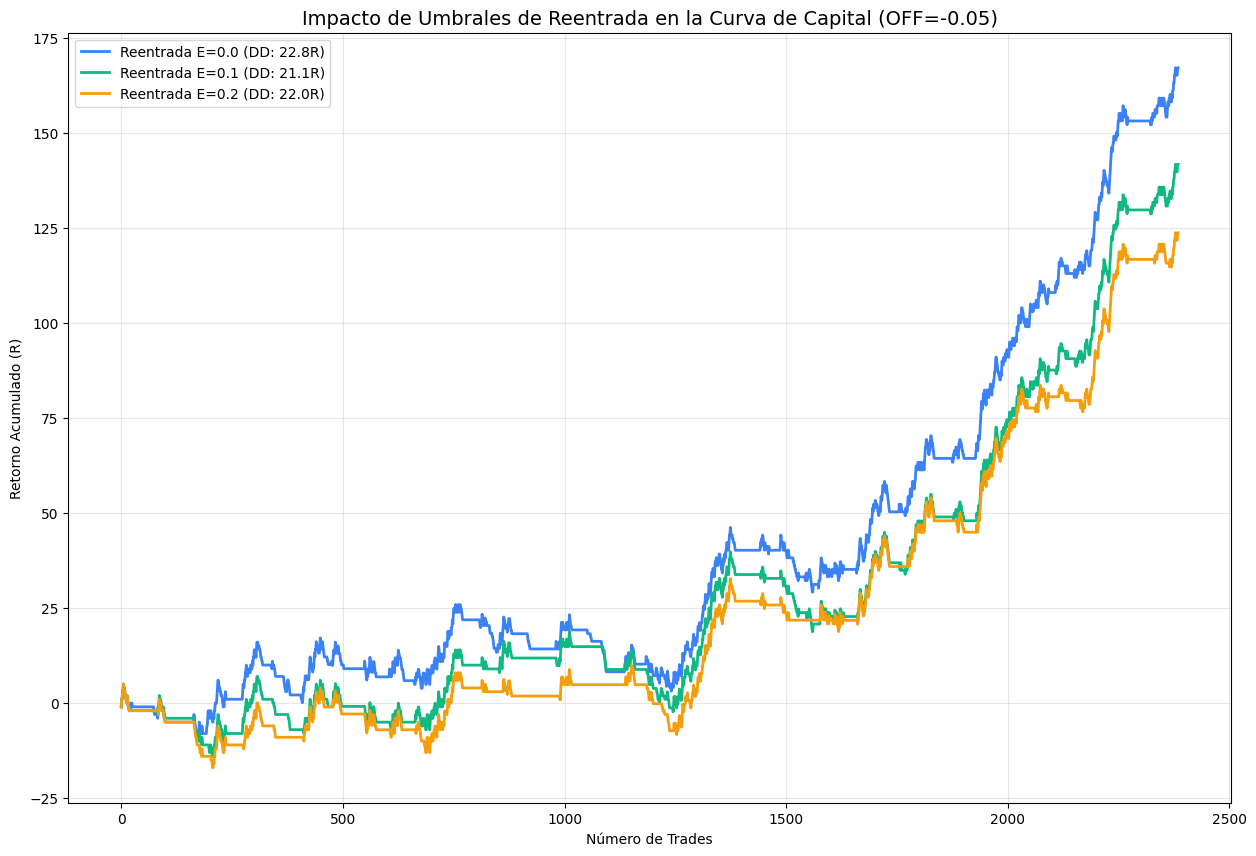

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_sentinel_asimetrico(df_trades, ventana_n=20, umbral_off=-0.05, umbral_on=0.0, usar_marea=False):
    """
    Motor Sentinel con Histéresis (Asimetría):
    - Se apaga en umbral_off.
    - Se enciende en umbral_on.
    """
    df = df_trades.copy()
    
    # Calcular esperanza móvil
    df['expectancy_rolling'] = df['pnl_r'].rolling(window=ventana_n).mean()
    exp_values = df['expectancy_rolling'].shift(1).fillna(0).values
    
    estado_on = True 
    sentinel_signals = []
    
    for exp in exp_values:
        if estado_on:
            if exp < umbral_off:
                estado_on = False
        else:
            if exp > umbral_on:
                estado_on = True
        sentinel_signals.append(estado_on)
    
    df['sentinel_on'] = sentinel_signals
    df['pnl_sentinel'] = np.where(df['sentinel_on'], df['pnl_r'], 0)
    
    return df

# --- BLOQUE DE PRUEBAS MULTI-UMBRAL ---
if 'df_final_results' in globals():
    # Dataset base (Marea OFF para ver potencia pura)
    df_base = df_final_results.sort_values('entrada_dt').reset_index(drop=True)
    
    reentradas = [0.0, 0.1, 0.2]
    U_OFF = -0.05
    N = 20
    
    plt.figure(figsize=(15, 10))
    colores = ['#3b82f6', '#10b981', '#f59e0b']
    
    print(f"📊 ANALISIS DE REENTRADAS ASIMÉTRICAS (OFF={U_OFF}R)")
    print("-" * 85)
    print(f"{'Umbral ON':<10} | {'Trades':<8} | {'Profit R':<12} | {'Max DD':<10} | {'PF':<6} | {'% Tiempo ON'}")
    print("-" * 85)

    for i, u_on in enumerate(reentradas):
        df_res = ejecutar_sentinel_asimetrico(df_base, ventana_n=N, umbral_off=U_OFF, umbral_on=u_on)
        
        # Métricas
        trades_on = df_res[df_res['sentinel_on']]
        pnl_final = trades_on['pnl_r'].sum()
        equity = df_res['pnl_sentinel'].cumsum()
        dd = (equity.cummax() - equity).max()
        
        ganancias = trades_on[trades_on['pnl_r'] > 0]['pnl_r'].sum()
        perdidas = abs(trades_on[trades_on['pnl_r'] < 0]['pnl_r'].sum())
        pf = ganancias / perdidas if perdidas != 0 else np.inf
        tiempo_on = (df_res['sentinel_on'].mean() * 100)
        
        print(f"E = {u_on:<6.1f} | {len(trades_on):<8} | {pnl_final:<12.2f} | {dd:<10.2f} | {pf:<6.2f} | {tiempo_on:.1f}%")
        
        plt.plot(equity.values, label=f'Reentrada E={u_on} (DD: {dd:.1f}R)', color=colores[i], lw=2)

    # Configuración de gráfico
    plt.title(f"Impacto de Umbrales de Reentrada en la Curva de Capital (OFF={U_OFF})", fontsize=14)
    plt.ylabel("Retorno Acumulado (R)")
    plt.xlabel("Número de Trades")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

else:
    print("🛑 Error: No se detecta 'df_final_results' en memoria.")

📊 ANÁLISIS DE REENTRADAS ASIMÉTRICAS (OFF=-0.05R | N=20)
-----------------------------------------------------------------------------------------------
Umbral ON  | Trades   | Profit R     | Max DD     | PF     | % Tiempo ON
-----------------------------------------------------------------------------------------------
E = 0.00   | 1481     | 167.07       | 22.78      | 1.28   | 62.1%
E = 0.02   | 1462     | 167.07       | 20.13      | 1.29   | 61.3%
E = 0.10   | 1340     | 141.68       | 21.13      | 1.26   | 56.2%
E = 0.20   | 1174     | 123.68       | 22.00      | 1.26   | 49.2%


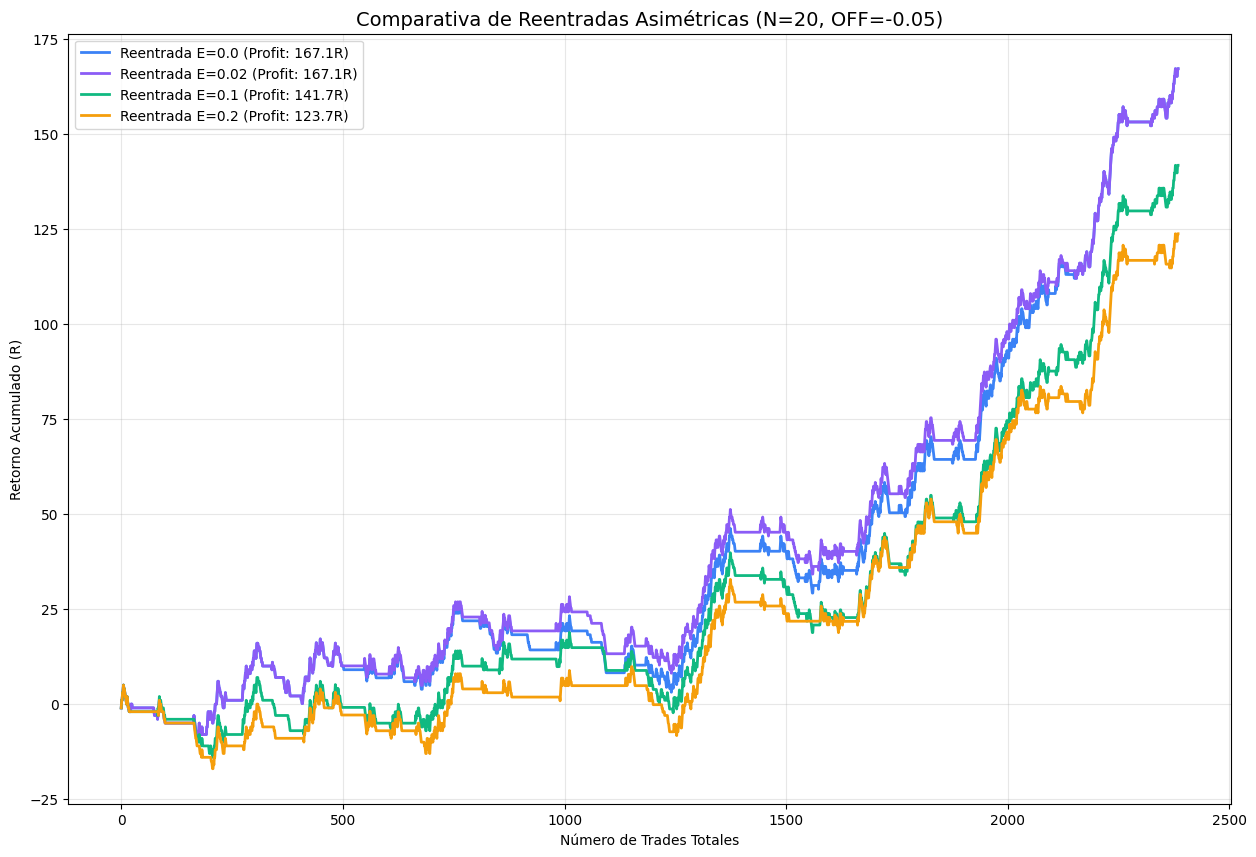

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_sentinel_asimetrico(df_trades, ventana_n=20, umbral_off=-0.05, umbral_on=0.0):
    """
    Motor Sentinel con Histéresis (Asimetría) corregido:
    - Evalúa la esperanza del pasado (shift 1) para decidir si opera el trade actual.
    - Mantiene el estado hasta que se cruza el umbral opuesto.
    """
    df = df_trades.copy()
    
    # Calcular esperanza móvil sobre el PnL de los trades
    df['expectancy_rolling'] = df['pnl_r'].rolling(window=ventana_n).mean()
    
    # IMPORTANTE: Usamos el shift(1) para no tener "look-ahead bias"
    # Decidimos si entramos al trade 'i' basándonos en el promedio hasta 'i-1'
    exp_values = df['expectancy_rolling'].shift(1).fillna(0).values
    
    estado_on = True # Iniciamos encendidos
    sentinel_signals = []
    
    for exp in exp_values:
        if estado_on:
            # Si cae por debajo del umbral de pánico, apagamos
            if exp < umbral_off:
                estado_on = False
        else:
            # Si supera el umbral de confianza, encendemos
            if exp > umbral_on:
                estado_on = True
        sentinel_signals.append(estado_on)
    
    df['sentinel_on'] = sentinel_signals
    df['pnl_sentinel'] = np.where(df['sentinel_on'], df['pnl_r'], 0)
    
    return df

# --- BLOQUE DE PRUEBAS MULTI-UMBRAL ---
if 'df_final_results' in globals():
    # Ordenar cronológicamente para que el rolling tenga sentido
    df_base = df_final_results.sort_values('entrada_dt').reset_index(drop=True)
    
    # Añadimos el 0.02 que mencionaste para validar el cuadre
    reentradas = [0.0, 0.02, 0.1, 0.2]
    U_OFF = -0.05
    N = 20
    
    plt.figure(figsize=(15, 10))
    colores = ['#3b82f6', '#8b5cf6', '#10b981', '#f59e0b']
    
    print(f"📊 ANÁLISIS DE REENTRADAS ASIMÉTRICAS (OFF={U_OFF}R | N={N})")
    print("-" * 95)
    print(f"{'Umbral ON':<10} | {'Trades':<8} | {'Profit R':<12} | {'Max DD':<10} | {'PF':<6} | {'% Tiempo ON'}")
    print("-" * 95)

    for i, u_on in enumerate(reentradas):
        df_res = ejecutar_sentinel_asimetrico(df_base, ventana_n=N, umbral_off=U_OFF, umbral_on=u_on)
        
        # Filtramos solo los trades donde el Sentinel dio luz verde
        trades_on = df_res[df_res['sentinel_on']]
        pnl_final = trades_on['pnl_r'].sum()
        
        # Equity curve considerando que cuando está OFF el capital es plano
        equity = df_res['pnl_sentinel'].cumsum()
        dd = (equity.cummax() - equity).max()
        
        # Métricas de eficiencia
        ganancias = trades_on[trades_on['pnl_r'] > 0]['pnl_r'].sum()
        perdidas = abs(trades_on[trades_on['pnl_r'] < 0]['pnl_r'].sum())
        pf = ganancias / perdidas if perdidas != 0 else np.inf
        tiempo_on = (df_res['sentinel_on'].mean() * 100)
        
        print(f"E = {u_on:<6.2f} | {len(trades_on):<8} | {pnl_final:<12.2f} | {dd:<10.2f} | {pf:<6.2f} | {tiempo_on:.1f}%")
        
        plt.plot(equity.values, label=f'Reentrada E={u_on} (Profit: {pnl_final:.1f}R)', color=colores[i], lw=2)

    plt.title(f"Comparativa de Reentradas Asimétricas (N={N}, OFF={U_OFF})", fontsize=14)
    plt.ylabel("Retorno Acumulado (R)")
    plt.xlabel("Número de Trades Totales")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

else:
    print("🛑 Error: No se detecta 'df_final_results' en memoria.")

📊 ANÁLISIS DE REENTRADAS ASIMÉTRICAS (OFF=-0.05R | N=20)
---------------------------------------------------------------------------------------------------------
Configuración   | Trades   | Profit R     | Max DD     | PF     | % Tiempo ON
---------------------------------------------------------------------------------------------------------
SIMÉTRICA       | 1538     | 163.07       | 23.78      | 1.26   | 64.5%
E = 0.00        | 1481     | 167.07       | 22.78      | 1.28   | 62.1%
E = 0.02        | 1462     | 167.07       | 20.13      | 1.29   | 61.3%
E = 0.10        | 1340     | 141.68       | 21.13      | 1.26   | 56.2%
E = 0.20        | 1174     | 123.68       | 22.00      | 1.26   | 49.2%


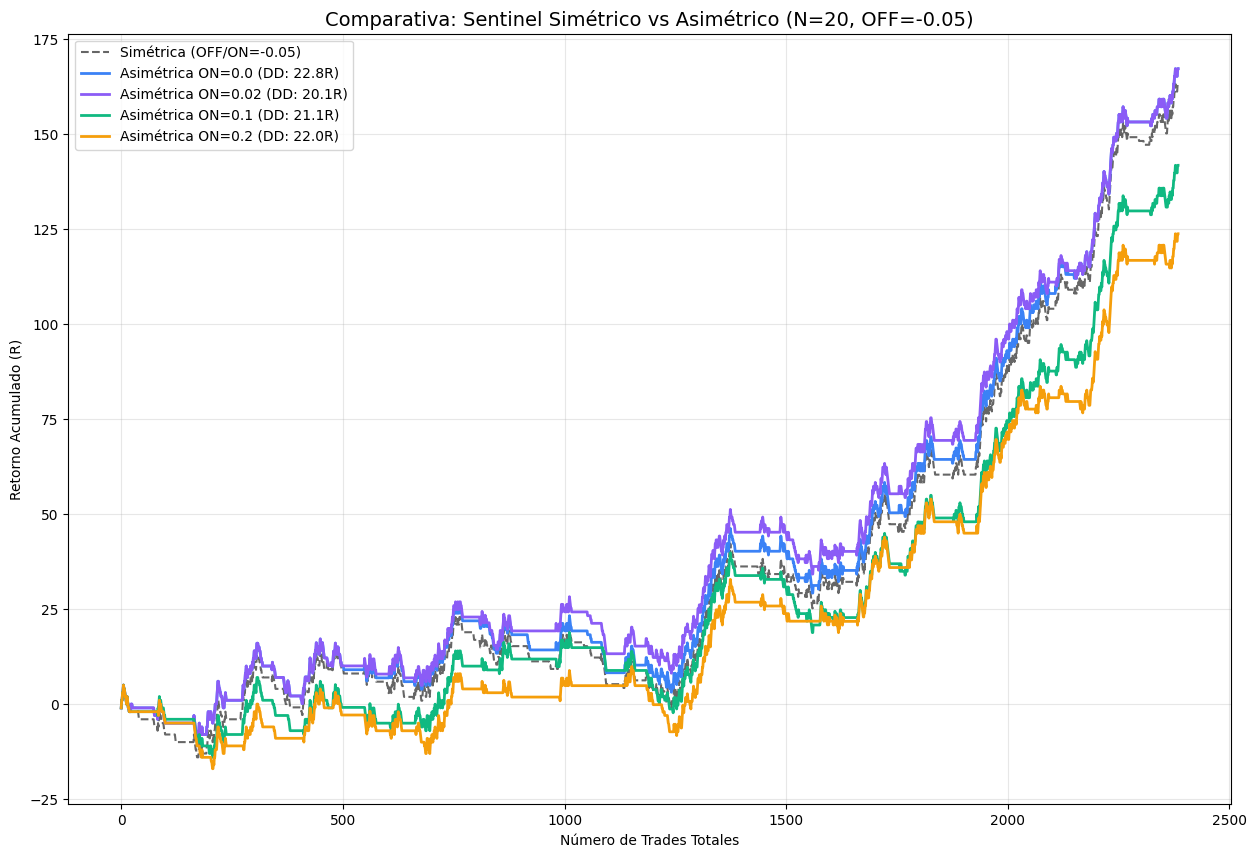

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_sentinel_asimetrico(df_trades, ventana_n=20, umbral_off=-0.05, umbral_on=0.0):
    """
    Motor Sentinel con Histéresis (Asimetría) corregido:
    - Evalúa la esperanza del pasado (shift 1) para decidir si opera el trade actual.
    - Mantiene el estado hasta que se cruza el umbral opuesto.
    """
    df = df_trades.copy()
    
    # Calcular esperanza móvil sobre el PnL de los trades
    df['expectancy_rolling'] = df['pnl_r'].rolling(window=ventana_n).mean()
    
    # IMPORTANTE: Usamos el shift(1) para no tener "look-ahead bias"
    # Decidimos si entramos al trade 'i' basándonos en el promedio hasta 'i-1'
    exp_values = df['expectancy_rolling'].shift(1).fillna(0).values
    
    estado_on = True # Iniciamos encendidos
    sentinel_signals = []
    
    for exp in exp_values:
        if estado_on:
            # Si cae por debajo del umbral de pánico, apagamos
            if exp < umbral_off:
                estado_on = False
        else:
            # Si supera el umbral de confianza, encendemos
            if exp > umbral_on:
                estado_on = True
        sentinel_signals.append(estado_on)
    
    df['sentinel_on'] = sentinel_signals
    df['pnl_sentinel'] = np.where(df['sentinel_on'], df['pnl_r'], 0)
    
    return df

# --- BLOQUE DE PRUEBAS MULTI-UMBRAL ---
if 'df_final_results' in globals():
    # Ordenar cronológicamente para que el rolling tenga sentido
    df_base = df_final_results.sort_values('entrada_dt').reset_index(drop=True)
    
    # Umbrales a probar (Asimétricos)
    reentradas = [0.0, 0.02, 0.1, 0.2]
    U_OFF = -0.05
    N = 20
    
    plt.figure(figsize=(15, 10))
    colores = ['#3b82f6', '#8b5cf6', '#10b981', '#f59e0b']
    
    print(f"📊 ANÁLISIS DE REENTRADAS ASIMÉTRICAS (OFF={U_OFF}R | N={N})")
    print("-" * 105)
    print(f"{'Configuración':<15} | {'Trades':<8} | {'Profit R':<12} | {'Max DD':<10} | {'PF':<6} | {'% Tiempo ON'}")
    print("-" * 105)

    # 1. EJECUCIÓN SIMÉTRICA (Referencia)
    df_sim = ejecutar_sentinel_asimetrico(df_base, ventana_n=N, umbral_off=U_OFF, umbral_on=U_OFF)
    trades_sim = df_sim[df_sim['sentinel_on']]
    equity_sim = df_sim['pnl_sentinel'].cumsum()
    dd_sim = (equity_sim.cummax() - equity_sim).max()
    pf_sim = trades_sim[trades_sim['pnl_r'] > 0]['pnl_r'].sum() / abs(trades_sim[trades_sim['pnl_r'] < 0]['pnl_r'].sum())
    
    print(f"{'SIMÉTRICA':<15} | {len(trades_sim):<8} | {trades_sim['pnl_r'].sum():<12.2f} | {dd_sim:<10.2f} | {pf_sim:<6.2f} | {(df_sim['sentinel_on'].mean()*100):.1f}%")
    plt.plot(equity_sim.values, label=f'Simétrica (OFF/ON={U_OFF})', color='black', linestyle='--', alpha=0.6, lw=1.5)

    # 2. EJECUCIÓN ASIMÉTRICA (Pruebas)
    for i, u_on in enumerate(reentradas):
        df_res = ejecutar_sentinel_asimetrico(df_base, ventana_n=N, umbral_off=U_OFF, umbral_on=u_on)
        
        trades_on = df_res[df_res['sentinel_on']]
        pnl_final = trades_on['pnl_r'].sum()
        equity = df_res['pnl_sentinel'].cumsum()
        dd = (equity.cummax() - equity).max()
        
        ganancias = trades_on[trades_on['pnl_r'] > 0]['pnl_r'].sum()
        perdidas = abs(trades_on[trades_on['pnl_r'] < 0]['pnl_r'].sum())
        pf = ganancias / perdidas if perdidas != 0 else np.inf
        tiempo_on = (df_res['sentinel_on'].mean() * 100)
        
        label_on = f"E = {u_on:<4.2f}"
        print(f"{label_on:<15} | {len(trades_on):<8} | {pnl_final:<12.2f} | {dd:<10.2f} | {pf:<6.2f} | {tiempo_on:.1f}%")
        
        plt.plot(equity.values, label=f'Asimétrica ON={u_on} (DD: {dd:.1f}R)', color=colores[i], lw=2)

    plt.title(f"Comparativa: Sentinel Simétrico vs Asimétrico (N={N}, OFF={U_OFF})", fontsize=14)
    plt.ylabel("Retorno Acumulado (R)")
    plt.xlabel("Número de Trades Totales")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

else:
    print("🛑 Error: No se detecta 'df_final_results' en memoria.")

🔍 RE-OPTIMIZACIÓN SENTINEL (Lógica Real con Shift 1)
----------------------------------------------------------------------------------------------------
N    | ON     | OFF    | Trades   | Profit R   | Max DD     | PF     | Exp
----------------------------------------------------------------------------------------------------
10   | -0.05  | -0.05  | 1466     | 107.14     | 25.93      | 1.18   | 0.073
10   | 0.00   | -0.05  | 1368     | 104.56     | 23.93      | 1.19   | 0.076
10   | 0.02   | -0.05  | 1363     | 106.56     | 23.93      | 1.19   | 0.078
15   | -0.05  | -0.05  | 1492     | 132.07     | 25.00      | 1.22   | 0.089
15   | 0.00   | -0.05  | 1435     | 120.07     | 19.00      | 1.21   | 0.084
15   | 0.02   | -0.05  | 1414     | 122.07     | 18.04      | 1.21   | 0.086
20   | -0.05  | -0.05  | 1538     | 163.07     | 23.78      | 1.26   | 0.106
20   | 0.00   | -0.05  | 1481     | 167.07     | 22.78      | 1.28   | 0.113
20   | 0.02   | -0.05  | 1462     | 167.07     | 20.13

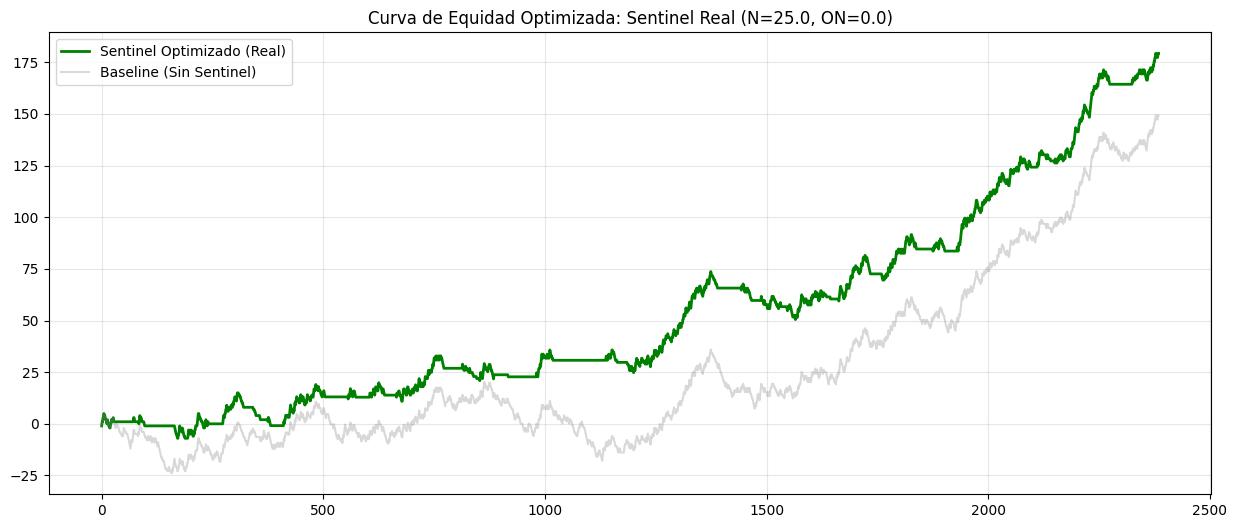

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_sentinel_real(df_trades, ventana_n=20, umbral_off=-0.05, umbral_on=0.0):
    """
    Motor Sentinel PROFESIONAL (Sin Sesgo de Futuro):
    - El estado para el Trade 'i' se decide EXCLUSIVAMENTE con la media de trades de 'i-ventana' hasta 'i-1'.
    - Implementa histéresis (asimetría) para filtrar el ruido en la transición de estados.
    """
    df = df_trades.copy()
    
    # 1. Calculamos la esperanza móvil con shift(1) para evitar Look-Ahead Bias
    df['expectancy_real'] = df['pnl_r'].rolling(window=ventana_n).mean().shift(1).fillna(0)
    
    exp_values = df['expectancy_real'].values
    estado_on = True # Empezamos asumiendo que el sistema es apto
    sentinel_signals = []
    
    # 2. Bucle de ejecución (Simula el paso del tiempo real)
    for exp in exp_values:
        if estado_on:
            if exp < umbral_off:
                estado_on = False
        else:
            if exp > umbral_on:
                estado_on = True
        sentinel_signals.append(estado_on)
    
    df['sentinel_on'] = sentinel_signals
    df['pnl_sentinel'] = np.where(df['sentinel_on'], df['pnl_r'], 0)
    
    return df

# --- BLOQUE DE RE-OPTIMIZACIÓN REAL ---
if 'df_final_results' in globals():
    # Asegurar orden cronológico y limpieza de datos
    df_base = df_final_results.sort_values('entrada_dt').reset_index(drop=True)
    
    # Definición de rangos para optimización
    ventanas = [10, 15, 20, 25, 30, 40, 50]
    umbrales_on = [-0.05, 0.0, 0.02, 0.05, 0.1] # Incluimos simétrico (-0.05) y asimétricos
    umbral_off_fijo = -0.05
    
    resultados = []

    print(f"🔍 RE-OPTIMIZACIÓN SENTINEL (Lógica Real con Shift 1)")
    print("-" * 100)
    print(f"{'N':<4} | {'ON':<6} | {'OFF':<6} | {'Trades':<8} | {'Profit R':<10} | {'Max DD':<10} | {'PF':<6} | {'Exp'}")
    print("-" * 100)

    for n in ventanas:
        for u_on in umbrales_on:
            df_res = ejecutar_sentinel_real(df_base, ventana_n=n, umbral_off=umbral_off_fijo, umbral_on=u_on)
            
            trades_on = df_res[df_res['sentinel_on']]
            pnl_f = trades_on['pnl_r'].sum()
            equity = df_res['pnl_sentinel'].cumsum()
            dd = (equity.cummax() - equity).max()
            
            # Métricas adicionales
            gan = trades_on[trades_on['pnl_r'] > 0]['pnl_r'].sum()
            per = abs(trades_on[trades_on['pnl_r'] < 0]['pnl_r'].sum())
            pf = gan / per if per != 0 else np.inf
            exp = pnl_f / len(trades_on) if len(trades_on) > 0 else 0
            
            resultados.append({
                'N': n, 'ON': u_on, 'OFF': umbral_off_fijo, 
                'Trades': len(trades_on), 'Profit': pnl_f, 
                'DD': dd, 'PF': pf, 'Exp': exp
            })
            
            # Mostrar solo los más relevantes o un resumen por ventana
            if u_on in [-0.05, 0.0, 0.02]:
                print(f"{n:<4} | {u_on:<6.2f} | {umbral_off_fijo:<6.2f} | {len(trades_on):<8} | {pnl_f:<10.2f} | {dd:<10.2f} | {pf:<6.2f} | {exp:.3f}")

    # Análisis del Ganador (Mejor Profit Factor con DD aceptable)
    df_opt = pd.DataFrame(resultados)
    ganador = df_opt.loc[df_opt['PF'].idxmax()]
    
    print("-" * 100)
    print(f"🏆 CONFIGURACIÓN GANADORA (Basada en PF): N={ganador['N']}, ON={ganador['ON']}, OFF={ganador['OFF']}")
    print(f"Profit: {ganador['Profit']:.2f}R | MaxDD: {ganador['DD']:.2f}R | PF: {ganador['PF']:.2f}")

    # Visualización del Ganador Real
    df_final = ejecutar_sentinel_real(df_base, ventana_n=int(ganador['N']), 
                                     umbral_off=ganador['OFF'], 
                                     umbral_on=ganador['ON'])
    
    plt.figure(figsize=(15, 6))
    plt.plot(df_final['pnl_sentinel'].cumsum().values, color='green', lw=2, label='Sentinel Optimizado (Real)')
    plt.plot(df_base['pnl_r'].cumsum().values, color='gray', alpha=0.3, label='Baseline (Sin Sentinel)')
    plt.title(f"Curva de Equidad Optimizada: Sentinel Real (N={ganador['N']}, ON={ganador['ON']})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

else:
    print("🛑 Error: No hay datos 'df_final_results' para optimizar.")